# The Unified Memory Advantage: Quantifying Throughput, Latency, and Energy Efficiency of Apple Silicon Inference Frameworks

## Introduction
While flagship large language models (LLMs) operate on proprietary models, multi-GPU clusters, the recent improvement of open-weight models and hardware efficiency allowed for self-hosted LLM inference on consumer hardware. istorically, this domain relies on NVIDIA CUDA architectures utilizing discrete consumer or entry-level workstation GPUs (e.g., RTX 40/50 series, L4). However, Apple Silicon has emerged as a structurally distinct alternative: Its unified memory architecture permits massive parameter caching and high-bandwidth memory access at a fraction of the energy required by discrete GPUs.

Despite this architectural shift, systematic benchmarks comparing Apple Silicon against CUDA across varying quantization algorithms, batch sizes, and serving frameworks remain sparse, largely confined to pre-print papers [1-4] and anecdotal observations on Reddit (such as [here](https://www.reddit.com/r/LocalLLaMA/comments/1qla41o/selfhosting_llm_infra_nvidia_vs_apple_hardware/) or [here](https://www.reddit.com/r/LocalLLaMA/comments/1bm2npm/self_hosted_ai_apple_m_processors_vs_nvidia_gpus/)). Furthermore, the Apple Silicon software ecosystem is currently divided into two branches: The established standard relies on `llama.cpp` [9] and its high-level wrapper, `Ollama` [8], utilizing the GGUF format and a custom Metal backend. Conversely, Apple's native and highly UMA-optimized MLX framework has spawned `mlx-lm` [10] and the recently developed `oMLX` [7] serving layer, the latter introducing several quality-of-life features such as SSD-backed tiered KV-caching. This project executes a two-fold investigation: first, a direct performance and energy efficiency comparison between Apple Silicon and CUDA hardware; second, an intra-ecosystem benchmarking of classical GGUF engines (`llama.cpp`, `Ollama`) against MLX-native equivalents (`mlx-lm`, `oMLX`).


### Background: Unified Memory and Apple Silicon Inference

#### Unified Memory on Apple Silicon

Traditional CUDA-based systems utilize a discrete GPU architecture: The CPU and GPU maintain separate physical memory pools (system DRAM and GDDR/HBM, respectively). This requires explicit, high-latency data transfers over the PCIe bus whenever tensors or model weights move between the host and device.

Apple Silicon (M-series chips) utilize a **unified memory architecture**:. A single shared DRAM pool is accessible simultaneously by the CPU, GPU, and Neural Engine at the hardware level.

For LLM inference, this architectural divergence yields two primary outcomes:
- Zero-Copy Execution: Model weights and Key-Value (KV) caches are accessed directly by either processor without duplication. This eliminates the PCIe bottleneck, which is critical for memory-bandwidth-bound generation phases.
- Energy Efficiency: Eradicating PCIe transfer overhead significantly reduces the thermal and power footprint, lowering per-token energy consumption compared to discrete GPUs.

The primary hardware limitation is the shared bandwidth budget. The CPU and GPU must compete for the same aggregate memory bandwidth (e.g., up to 800 GB/s on M-class Ultra chips), whereas high-end discrete GPUs possess dedicated HBM with peak bandwidths exceeding 2 TB/s.

#### Metal and MLX

Metal is Apple's foundational, low-level hardware-accelerated compute API. Programs can implement direct Metal backends to utilize custom Metal kernels to execute tensor operations. This requires manual memory buffer management, explicit kernel dispatch, and eager execution, but grants developers granular control over the hardware pipeline and zero-copy unified memory mapping.

On the other hand, MLX is a heavily optimized array framework building on top of Metal: Key features include **true shared memory** (i.e., no host-to-device transfers), **lazy evaluation** (enabling aggressive kernel fusion and reduced intermediate allocations), and **hand-tuned Metal kernels** optimized for the specific cache hierarchies and bandwidth characteristics of Apple Silicon SoCs. The abstraction allows `mlx-lm` and `oMLX`, that both build on MLX, to implement LLM inference pipelines with lower development overhead, frequently achieving superior throughput and energy efficiency metrics compared to engines requiring manual, monolithic Metal kernel maintenance.



#### `Llama.cpp` and the GGUF Format

`llama.cpp` is a C++ inference engine designed for cross-platform portability. It relies on the GGUF format, a serialization standard that packages model weights, tokenizers, and execution metadata into a single binary file. GGUF enables zero-copy, memory-mapped loading and supports multiple variable-bitrate quantization algorithms (e.g., K-quants), allowing precise tuning of the memory footprint versus output fidelity tradeoff. It does not rely on MLX, but instead implements its own custom Metal backend to run on Apple Silicon, which is not as aggressively optimized as MLX.


### Evaluated Inference Engines
Our experiments are going to evaluate the following low-level inference engines:
- `llama.cpp`: The low-level C++ inference engine executing GGUF-quantized weights. It functions as the cross-platform baseline, executing via the native Metal API on Apple Silicon and via CUDA on the remote cluster.
- `mlx-lm`: The native MLX-based inference engine optimized strictly for Apple Silicon. It serves as the baseline for evaluating raw throughput and hardware-level energy efficiency within the Apple ecosystem.

In addition, we evaluate the following higher-level serving frameworks:
- `Ollama`: The established high-level serving engine built on top of `llama.cpp`. It provides an OpenAI-compatible API and serves as the direct architectural counterpart to `oMLX` in the concurrent serving benchmarks.
- `oMLX`: A production-oriented HTTP serving layer built on top of `mlx-lm`. It introduces advanced features, such as SSD-backed tiered KV-caching. Evaluated to quantify high-level serving overhead and multi-session memory management on Apple Silicon.

### Overview of experiments
Our experiments are structured into three main parts, each designed to isolate and evaluate different aspects of the inference stack:
1. **Experiment 1: Raw Engine Benchmarking (`mlx-lm` vs. `llama.cpp`)**: Measures low-level inference throughput across quantization levels (Exp 1a) and batch sizes (Exp 1b), comparing `mlx-lm` and `llama.cpp` on Apple Silicon as well as `llama.cpp` on a remote CUDA cluster.
2. **Experiment 2: Energy Benchmarks**: Measures energy consumption per token for `mlx-lm` and `llama.cpp`, comparing the Apple Silicon frameworks against a CUDA setup, and discusses implications for operational cost.
3. **Experiment 3: Higher-Level Serving Engine Benchmark (`oMLX` vs. `Ollama`)**: Measures the performance overhead introduced by the higher-level serving layer (Exp 3a) and evaluates one practical aspect of higher-level serving, namely multi-conversation settings (Exp 3b), on Apple Silicon and CUDA.

## Setup
This section describes the hardware and software setup for our experiments.

### Local Hardware
We run our experiments on a MacBook Air M4 with 24GB of RAM. Due to the fanless design of the laptop and the intensive nature of LLM inference, we have set up a manual fan-cooling solution to prevent thermal throttling during benchmarks (see image below). As this laptop is used primarily as a personal device, we cannot guarantee the absence of background processes during benchmarks, but we have closed all non-essential applications and processes to minimise interference.

<center>
<img src="./images/cooling_setup.jpeg" width="600">
</center>


### Software dependencies
This notebook depends on installations of `llama.cpp`, `Ollama`, and `oMLX`, as well as Qwen2.5-7B and Qwen2.5-14B models of appropriate quantisation for each framework. These can be obtained automatically by running the following scripts in the `scripts/` directory: `setup_omlx.sh` (requires `brew` for installing the framework and `uv` for downloading models via the Hugging Face CLI), `setup_ollama.sh` (requires `brew`), and setup_llama_cpp.sh (requires `cmake` for building the repository and `uv` for downloading models via the Hugging Face CLI). The remaining Python dependencies are listed in pyproject.toml and can be installed via `CMAKE_ARGS="-DGGML_METAL=on" uv sync --extra mlx --no-cache`.

In [ ]:
!chmod +x ./scripts/setup_ollama.sh ./scripts/setup_omlx.sh ./scripts/setup_llama_cpp.sh
!./scripts/setup_ollama.sh
!./scripts/setup_omlx.sh
!./scriptssetup_llama_cpp.sh metal

In [1]:
%reload_ext autoreload
%autoreload 2

import asyncio
import json
import os
import re
import signal
import statistics
import subprocess
import sys
import tempfile
import time
from collections import defaultdict
from contextlib import asynccontextmanager
from dataclasses import dataclass
from enum import Enum
from typing import Literal, Self

import aiohttp
import matplotlib.pyplot as plt
import numpy as np
import paramiko
import psutil
from faker import Faker

import llama_cpp
import mlx_lm
from transformers import AutoTokenizer
from zeus.device.soc.apple import AppleSiliconMeasurement
from zeus.monitor.energy import ZeusMonitor, Measurement

### Additional setup for remote CUDA experiments
To run CUDA experiments via SSH, this notebook additionally requires access to a remote machine with an NVIDIA GPU and CUDA installed, with the same models and Ollama framework available. It also requires a copy of this repository (see [GitHub](https://github.com/AndreasPlt/mlx-vs-llama)) on the remote machine, which contains the relevant setup and benchmark scripts. The connection details can be configured via the `REMOTE_HOST`, `REMOTE_USERNAME`, `SSH_KEY_PATH`, `REMOTE_CUDA_VISIBLE_DEVICES`, and `REMOTE_REPO_PATH` variables below. In our case, we use the ACS cluster of the University of Cambridge's CST department, on a machine with an NVIDIA L4 GPU with 24GB of VRAM.

### Global benchmark protocol
Each benchmark is run three times; we report the mean and standard deviation of the relevant metrics across these runs. Where supported, a warmup run is performed either once before the three runs or before each individual run, depending on the framework and benchmark type. This ensures measurement of steady-state performance, unaffected by model loading, JIT compilation, or other one-time initialisation costs.

In [2]:
# Benchmark protocol
WARMUP_RUNS = 1
REPEAT_RUNS = 3
APPLE_COOLDOWN_TIME = 30  # seconds


# Remote cluster configuration
REMOTE_REPO_PATH = "mini_projects/l46-mlsys"
REMOTE_HOST = "dev-gpu-acs.cl.cam.ac.uk"
REMOTE_USERNAME = "ap2535"
REMOTE_CUDA_VISIBLE_DEVICES = 1  # Set to the appropriate GPU ID(s) on the cluster
SSH_KEY_PATH = os.path.expanduser("~/.ssh/id_ed25519")


# Exp 1 and 2: Raw engine benchmarks
PROMPT_TOKENS = 1024
GENERATION_TOKENS = 512
BATCH_SIZES = [1, 2, 4, 8, 16]

# Exp 2: Energy measurement
IDLE_SECONDS = 10

# Exp 3: o-engine serving benchmark
OLLAMA_DEFAULT_PORT = 11434
OMLX_DEFAULT_PORT = 10240

SYSTEM_PROMPT_TOKENS = 1024
USER_MSG_TOKENS = 1024
MAX_CYCLE_TOKENS = 128
NUM_CYCLES = 10
AGENTS = ["A", "B", "C", "D"]
PER_AGENT_CONTEXT_LENGTH = 22_000
SYSTEM_PROMPT_SEED_BASE = 200
USER_PROMPT_SEED_BASE = 1000
USER_PROMPT_SEED_OFFSET = 100
WARMUP_SYSTEM_PROMPT_TOKENS = 32
WARMUP_INPUT_TOKENS = 32
WARMUP_OUTPUT_TOKENS = 8

In [4]:
# setup on remote machine
with paramiko.SSHClient() as ssh:
    ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
    ssh.connect(REMOTE_HOST, username=REMOTE_USERNAME, key_filename=SSH_KEY_PATH)
    cmd = f'cd {REMOTE_REPO_PATH} && chmod +x scripts/setup_ollama.sh scripts/setup_llama_cpp.sh && ./scripts/setup_ollama.sh && ./scripts/setup_llama_cpp.sh cuda && CMAKE_ARGS="-DGGML_CUDA=on" uv sync --extra cuda --no-cache'
    stdin, stdout, stderr = ssh.exec_command(f"zsh -l -c '{cmd}'")
    exit_status = stdout.channel.recv_exit_status()
    if exit_status != 0:
        err = stderr.read().decode()
        print(f"Error running remote benchmark: {err}")
    else:
        print("Remote benchmark setup completed successfully")

Remote benchmark setup completed successfully


Note that MLX models and GGUF models use different quantisation schemes: MLX uses linear 4-bit or 8-bit quantisation, whereas GGUF uses k-means clustering-based quantisation for 4-bit and linear quantisation for 8-bit. Additionally, the MLX 16-bit model uses the bfloat16 data type, while the GGUF 16-bit model uses float16. Consequently, identical outputs across frameworks cannot be guaranteed, and model outputs are not compared for accuracy; only for performance and efficiency. To maximise determinism across frameworks, all benchmarks use a temperature of 0, `top-p` of 1.0, and `top-k` of 0.

In [3]:
class Quantization(Enum):
    FP16 = "FP16"
    INT8 = "INT8"
    INT4 = "INT4"

    def to_mlx_model_name(self, model_size: Literal["7B", "14B"] = "7B") -> str:
        if self == Quantization.FP16:
            return f"mlx-community/Qwen2.5-{model_size}-Instruct-bf16"
        elif self == Quantization.INT8:
            return f"mlx-community/Qwen2.5-{model_size}-Instruct-8bit"
        elif self == Quantization.INT4:
            return f"mlx-community/Qwen2.5-{model_size}-Instruct-4bit"
        else:
            raise ValueError(f"Unsupported quantization: {self}")

    def to_ttuf_model_name(self, model_size: Literal["7B", "14B"] = "7B") -> str:
        if self == Quantization.FP16:
            return f"models/qwen2.5-{model_size.lower()}/Qwen2.5-{model_size}-Instruct-f16.gguf"
        elif self == Quantization.INT8:
            return f"models/qwen2.5-{model_size.lower()}/Qwen2.5-{model_size}-Instruct-Q8_0.gguf"
        elif self == Quantization.INT4:
            return f"models/qwen2.5-{model_size.lower()}/Qwen2.5-{model_size}-Instruct-Q4_K_M.gguf"
        else:
            raise ValueError(f"Unsupported quantization: {self}")
        
    def to_ollama_model_name(self, model_size: Literal["7B", "14B"] = "7B") -> str:
        if self == Quantization.FP16:
            return f"qwen2.5:{model_size.lower()}-instruct-fp16"
        elif self == Quantization.INT8:
            return f"qwen2.5:{model_size.lower()}-instruct-q8_0"
        elif self == Quantization.INT4:
            return f"qwen2.5:{model_size.lower()}-instruct-q4_K_M"
        else:
            raise ValueError(f"Unsupported quantization: {self}")


@dataclass
class BenchmarkResults:
    pp_tps_mean: float
    pp_tps_std: float
    gen_tps_mean: float
    gen_tps_std: float
    batch_size: int
    pp_tokens: int
    gen_tokens: int

    @property
    def time_to_first_token(self) -> float:
        return self.pp_tokens * self.batch_size / self.pp_tps_mean

    @property
    def time_per_output_token(self) -> float:
        return self.gen_tokens * self.batch_size / self.gen_tps_mean / self.gen_tokens
    
    @classmethod
    def from_dict(cls, data: dict) -> Self:
        return cls(**data)


@dataclass
class QuantLevelResults:
    framework: Literal["MLX", "LLAMA_CPP_METAL", "LLAMA_CPP_CUDA"]
    benchmark_results: dict[Quantization, BenchmarkResults]


@dataclass
class BatchSizeResults:
    framework: Literal["MLX", "LLAMA_CPP_METAL", "LLAMA_CPP_CUDA"]
    benchmark_results: dict[int, BenchmarkResults]


@dataclass
class Experiment1aResult:
    mlx_results: QuantLevelResults
    llama_cpp_metal_results: QuantLevelResults
    llama_cpp_cuda_results: QuantLevelResults

## Experiment 1: Raw Engine Benchmarking (mlx-lm vs. llama.cpp)
We first benchmark the raw performance of the mlx-lm and llama.cpp engines for LLM inference on Apple Silicon, using the Qwen2.5-7B model family. We selected these models because they are available in the required quantisation formats for both frameworks and are small enough to run on our hardware without out-of-memory issues, even for the unquantised 16-bit variants. The goal of this experiment is to quantify the performance gap between the highly optimised MLX-based engine and the more general-purpose llama.cpp engine with an MPS backend, and to compare Apple Silicon inference performance against CUDA.
To capture different aspects of inference performance, we measure the following metrics:

- **Prefill/prompt processing throughput**: the number of tokens processed per second during the prefill phase (i.e. processing the input prompt). As prefill is typically compute-bound, this metric reflects the engine's efficiency in hardware utilisation, as well as the underlying hardware capabilities itself.
- **Time-to-first-token (TTFT)**: the elapsed time from sending an inference request to receiving the first generated token. TTFT is governed primarily by prefill throughput and batch size, and is a key indicator of perceived latency and user experience.
- **Decode/generation throughput**: the number of tokens generated per second after the first token. This reflects the steady-state generation performance of the engine, and is influenced by factors such as memory bandwidth and access latency.
- **Time-per-output-token (TPOT)**: the time taken to generate each token after the first. TPOT is the inverse of decode throughput at batch size 1, and, like TTFT, directly determines the perceived responsiveness of the engine during generation.

In each experiment run, we set the prompt length to TODO tokens and the generation length to TODO tokens. Inference workloads vary widely in prompt and generation length; these values were chosen as representative of a realistic single-user inference workload and provide a meaningful signal of engine performance under moderate load.

### Experiment 1a: Quantisation Scaling
We first compare inference speed across quantisation levels (4-bit integer, 8-bit integer, and 16-bit bfloat16) for the Qwen2.5-7B model on both engines. This experiment is restricted to a batch size of 1, the most common setting for consumer-hosted LLM inference. At batch size 1, latency is simply the inverse of throughput; we therefore report throughput only.
This allows us to assess how effectively each engine exploits quantisation to improve inference speed, and whether the engines differ in their handling of different quantisation formats. Since FLOPS and memory bandwidth differ substantially between NVIDIA and Apple Silicon, we hypothesise that the relative gains from quantisation might differ across platforms. The experiment is designed to isolate and quantify this effect on each platform independently.

#### Implementation
To benchmark mlx-lm, we use the `mlx_lm benchmark` CLI tool provided by the `mlx-lm` package. It provides a straightforward interface for measuring the relevant metrics, with built-in support for prefill throughput, decode throughput, warmup iterations, measurement iterations, cooldown time, and input/output lengths. The tool is invoked for each quantisation level as a subprocess from the notebook; its output is parsed to extract the relevant metrics:

In [6]:
def parse_mlx_output(output: str) -> BenchmarkResults:
    settings_pattern = re.compile(
        r"prompt_tokens=(\d+),\s+generation_tokens=(\d+),\s+batch_size=(\d+)"
    )
    settings_match = settings_pattern.search(output)
    if not settings_match:
        raise ValueError("Could not find settings line in mlx output")
    prompt_tokens = int(settings_match.group(1))
    generation_tokens = int(settings_match.group(2))
    batch_size = int(settings_match.group(3))

    trial_pattern = re.compile(
        r"Trial\s+\d+:\s+prompt_tps=([\d.]+),\s+generation_tps=([\d.]+)"
    )
    pp_values, gen_values = [], []
    for m in trial_pattern.finditer(output):
        pp_values.append(float(m.group(1)))
        gen_values.append(float(m.group(2)))

    if not pp_values:
        raise ValueError("No trial lines found in mlx output")

    return BenchmarkResults(
        pp_tps_mean=statistics.mean(pp_values),
        pp_tps_std=statistics.stdev(pp_values) if len(pp_values) > 1 else 0.0,
        gen_tps_mean=statistics.mean(gen_values),
        gen_tps_std=statistics.stdev(gen_values) if len(gen_values) > 1 else 0.0,
        batch_size=batch_size,
        pp_tokens=prompt_tokens,
        gen_tokens=generation_tokens,
    )


def build_mlx_command(quantization: Quantization, batch_size: int) -> list[str]:
    return [
        "mlx_lm", "benchmark",
        "--model", quantization.to_mlx_model_name(),
        "-n", str(REPEAT_RUNS),
        "-p", str(PROMPT_TOKENS),
        "-g", str(GENERATION_TOKENS),
        "--delay", str(APPLE_COOLDOWN_TIME),
        "--batch-size", str(batch_size),
    ]


def run_mlx_benchmark_single_quantization(quantization: Quantization, batch_size: int) -> BenchmarkResults:
    cmd = build_mlx_command(quantization, batch_size)
    temp_stdout = tempfile.TemporaryFile()
    proc = subprocess.Popen(cmd, stdout=temp_stdout, stderr=subprocess.DEVNULL)
    proc.wait()
    temp_stdout.seek(0)
    output = temp_stdout.read().decode("utf-8")
    temp_stdout.close()
    return parse_mlx_output(output)


def run_mlx_quant_level_benchmark() -> QuantLevelResults:
    results = {}
    for quantization in Quantization:
        print(f"Running MLX benchmark for quantization: {quantization.name}")
        results[quantization] = run_mlx_benchmark_single_quantization(quantization, batch_size=1)
    return QuantLevelResults(framework="MLX", benchmark_results=results)

In [7]:
mlx_quant_level_bench_results = run_mlx_quant_level_benchmark()

Running MLX benchmark for quantization: FP16
Running MLX benchmark for quantization: INT8
Running MLX benchmark for quantization: INT4


`llama.cpp` provides a similar benchmarking tool with `llama-bench`. However, it does not support measuring prefill and decode throughput separately; only combined throughput is reported. We therefore run two separate benchmarks:

- **Prefill throughput:** the benchmark is run with a prompt length of TODO tokens and a generation length of 0 tokens, isolating the prefill phase.
- **Decode throughput:** the benchmark is run with a prompt length of 0 tokens and a generation length of TODO tokens. To ensure that generated tokens attend to the same prompt context, we set the context depth to TODO tokens, matching the prefill prompt length used in the prefill benchmark. `llama.cpp` populates a static KV cache accordingly; this does not affect the generation throughput.

In both cases, results are output in JSON format, which we parse to extract the relevant values:

In [8]:
def parse_llama_output(pp_output: str, tg_output: str) -> BenchmarkResults:
    pp_data = json.loads(pp_output)[0]
    tg_data = json.loads(tg_output)[0]
    return BenchmarkResults(
        pp_tps_mean=pp_data["avg_ts"],
        pp_tps_std=pp_data["stddev_ts"],
        gen_tps_mean=tg_data["avg_ts"],
        gen_tps_std=tg_data["stddev_ts"],
        pp_tokens=pp_data["n_prompt"],
        gen_tokens=tg_data["n_gen"],
        batch_size=1,
    )


def build_llama_run_command(quantization: Quantization, is_prompt: bool, delay: bool) -> list[str]:
    base_cmd = [
        "./llama.cpp/build/bin/llama-bench",
        "--model", quantization.to_ttuf_model_name(),
        "-r", str(REPEAT_RUNS),
        "-o", "json",
    ]
    if delay:
        base_cmd += ["--delay", str(APPLE_COOLDOWN_TIME)]
    if is_prompt:
        return base_cmd + ["-p", str(PROMPT_TOKENS), "-n", "0"]
    else:
        return base_cmd + [
            "-p", "0",
            "-n", str(GENERATION_TOKENS),
            "-d", str(PROMPT_TOKENS),  # set decode context to prompt tokens for accurate TG-TPS
        ]

In [9]:
def run_llama_metal_benchmark_single_quantization(quantization: Quantization) -> BenchmarkResults:
    # need to run two commands, as llama.cpp does not report PP-TPS and TG-TPS separately
    pp_cmd = build_llama_run_command(quantization, is_prompt=True, delay=True)
    tg_cmd = build_llama_run_command(quantization, is_prompt=False, delay=True)

    pp_temp_stdout = tempfile.TemporaryFile()
    pp_proc = subprocess.Popen(
        pp_cmd,
        stdout=pp_temp_stdout,
        stderr=subprocess.DEVNULL,
    )
    pp_proc.wait()

    tg_temp_stdout = tempfile.TemporaryFile()
    tg_proc = subprocess.Popen(
        tg_cmd,
        stdout=tg_temp_stdout,
        stderr=subprocess.DEVNULL,
    )
    tg_proc.wait()

    pp_temp_stdout.seek(0)
    pp_output = pp_temp_stdout.read().decode("utf-8")
    pp_temp_stdout.close()

    tg_temp_stdout.seek(0)
    tg_output = tg_temp_stdout.read().decode("utf-8")
    tg_temp_stdout.close()

    return parse_llama_output(pp_output, tg_output)

def run_llama_metal_quant_levels_benchmark() -> QuantLevelResults:
    results = {}
    for quantization in Quantization:
        print(f"Running Llama.cpp (METAL) benchmark for quantization: {quantization.name}")
        benchmark_result = run_llama_metal_benchmark_single_quantization(quantization)
        results[quantization] = benchmark_result
    return QuantLevelResults(framework="LLAMA_CPP_METAL", benchmark_results=results)

In [ ]:
llama_metal_bench_results = run_llama_metal_quant_levels_benchmark()

To obtain results for the CUDA backend, the same command is executed via SSH on the remote machine with the NVIDIA GPU. The output is likewise in JSON format and parsed identically:

In [11]:
def run_llama_cuda_benchmark_single_quantization(quantization: Quantization, cuda_device: int = 0) -> BenchmarkResults:
    # run the same commands as for METAL on the cluster via ssh (paramiko)
    chdir_prefix = f"cd {REMOTE_REPO_PATH}"
    cuda_device_prefix = f"CUDA_VISIBLE_DEVICES={cuda_device}"
    pp_cmd = f"{chdir_prefix} && {cuda_device_prefix} " + ' '.join(build_llama_run_command(quantization, is_prompt=True, delay=False))
    tg_cmd = f"{chdir_prefix} && {cuda_device_prefix} " + ' '.join(build_llama_run_command(quantization, is_prompt=False, delay=False))

    with paramiko.SSHClient() as ssh:
        ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        ssh.connect(REMOTE_HOST, username=REMOTE_USERNAME, key_filename=SSH_KEY_PATH)
        # run prefill benchmark
        stdin, stdout, stderr = ssh.exec_command(f"zsh -l -c '{pp_cmd}'")
        exit_status = stdout.channel.recv_exit_status()
        if exit_status != 0:
            err = stderr.read().decode()
            print(f"Error running remote prefill benchmark: {err}")
            raise RuntimeError(f"Remote prefill benchmark failed with status {exit_status}. Command: {pp_cmd}")

        pp_output= stdout.read().decode()
        # run generation benchmark
        stdin, stdout, stderr = ssh.exec_command(f"zsh -l -c '{tg_cmd}'")
        exit_status = stdout.channel.recv_exit_status()
        if exit_status != 0:
            err = stderr.read().decode()
            print(f"Error running remote generation benchmark: {err}")
            raise RuntimeError(f"Remote generation benchmark failed with status {exit_status}. Command: {tg_cmd}")
        tg_output = stdout.read().decode()

    return parse_llama_output(pp_output, tg_output)

def run_llama_cuda_quant_levels_benchmark(cuda_device: int = 0) -> QuantLevelResults:
    results = {}
    for quantization in Quantization:
        print(f"Running Llama.cpp (CUDA) benchmark for quantization: {quantization.name}")
        benchmark_result = run_llama_cuda_benchmark_single_quantization(quantization, cuda_device=cuda_device)
        results[quantization] = benchmark_result
    return QuantLevelResults(framework="LLAMA_CPP_CUDA", benchmark_results=results)

In [ ]:
llama_cuda_bench_results = run_llama_cuda_quant_levels_benchmark(cuda_device=REMOTE_CUDA_VISIBLE_DEVICES)

#### Results 
Results are visualised in the plot below. For prefill throughput, we observe that performance remains broadly constant across quantisation levels, which is expected given that prefill is compute-bound. Prefill throughput is also closely matched between `mlx-lm` and `llama.cpp` on Apple Silicon, with `mlx-lm` showing a slight advantage at 4-bit quantisation and a slight disadvantage at 8-bit, which we attribute to minor differences in quantisation scheme and framework-level implementation. By contrast, there is a substantial gap between Apple Silicon and CUDA: the L4 GPU achieves approximately 15x higher prefill throughput across all quantisation levels, consistent with the large difference in raw compute capability (M4: 4.3 TFLOPS FP16; L4: 30.3 TFLOPS FP16) and the compute-bound nature of prefill.

For decode throughput, the picture is more nuanced. On Apple Silicon, `mlx-lm` has a significant advantage over `llama.cpp` at 4-bit quantisation, achieving approximately 25% higher throughput, likely attributable to more aggressive kernel fusion and memory management optimisations in `mlx-lm`. This advantage narrows at 8-bit precision and disappears entirely at 16-bit, where `llama.cpp` holds a marginal edge. The gap to the CUDA backend is also considerably smaller for decode than for prefill: the L4 achieves only around 2–2.5x higher decode throughput across all quantisation levels. Since decode is memory-bandwidth-bound, this ratio is directly proportional to the difference in memory bandwidth (M4: 120 GB/s; L4: 300.1 GB/s). Across all engines and quantisation levels, decode throughput scales inversely with bit-width as expected, indicating that all frameworks effectively exploit quantisation to accelerate inference.

/var/folders/tt/q795wc352hldv655c77_4cq80000gn/T/ipykernel_56148/1291408669.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0, 1, 1])


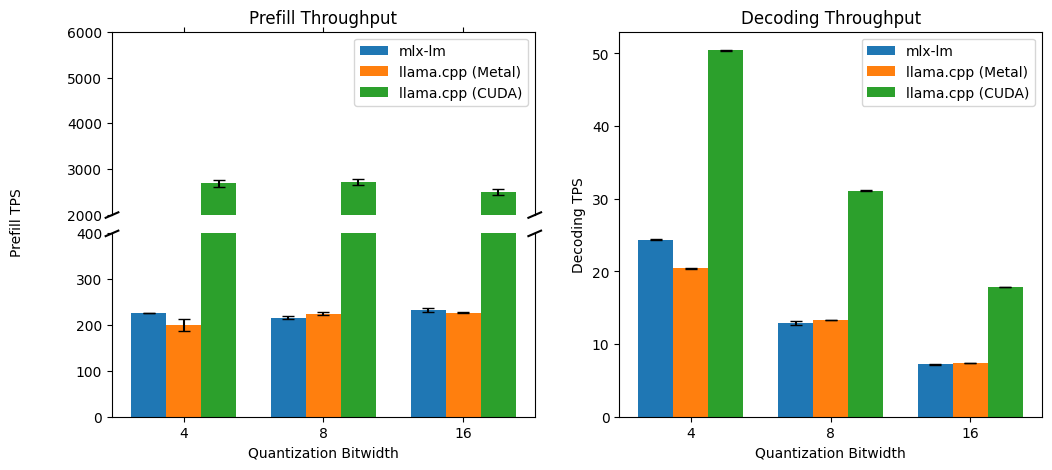

In [63]:
# Map quantization to bitwidth for x-axis
import matplotlib.gridspec as gridspec
bitwidth = {Quantization.INT4: 4, Quantization.INT8: 8, Quantization.FP16: 16}
quants = [Quantization.INT4, Quantization.INT8, Quantization.FP16]
x_labels = [bitwidth[q] for q in quants]
x = np.arange(len(quants))
bar_width = 0.25

frameworks = [
    ("mlx-lm", mlx_quant_level_bench_results),
    ("llama.cpp (Metal)", llama_metal_bench_results),
    ("llama.cpp (CUDA)", llama_cuda_bench_results),
]

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.1)

ax_pp_top = fig.add_subplot(gs[0, 0])
ax_pp_bot = fig.add_subplot(gs[1, 0], sharex=ax_pp_top)
ax_gen = fig.add_subplot(gs[:, 1])

# Plot Prefill Throughput on both top and bottom axes
for i, (label, fw) in enumerate(frameworks):
    means = [getattr(fw.benchmark_results[q], "pp_tps_mean") for q in quants]
    stds = [getattr(fw.benchmark_results[q], "pp_tps_std") for q in quants]
    
    ax_pp_top.bar(x + i * bar_width, means, bar_width, yerr=stds, label=label, capsize=4)
    ax_pp_bot.bar(x + i * bar_width, means, bar_width, yerr=stds, label=label, capsize=4)

# Set y-axis limits for the broken axis
# Adjust these values based on actual max/min throughputs
ax_pp_top.set_ylim(2000, 6000) 
ax_pp_bot.set_ylim(0, 400)      

# Hide spines between top and bottom axes
ax_pp_top.spines['bottom'].set_visible(False)
ax_pp_bot.spines['top'].set_visible(False)
ax_pp_top.xaxis.tick_top()
ax_pp_top.tick_params(labeltop=False)
ax_pp_bot.xaxis.tick_bottom()

# Add diagonal lines to indicate the break
d = .015 
kwargs = dict(transform=ax_pp_top.transAxes, color='k', clip_on=False)
ax_pp_top.plot((-d, +d), (-d, +d), **kwargs)        
ax_pp_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  
kwargs.update(transform=ax_pp_bot.transAxes)  
ax_pp_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)  
ax_pp_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  

ax_pp_bot.set_xlabel("Quantization Bitwidth")
ax_pp_top.set_title("Prefill Throughput")
ax_pp_bot.set_xticks(x + bar_width)
ax_pp_bot.set_xticklabels(x_labels)
ax_pp_top.legend()

# Set a common y-label for the broken axis
fig.text(0.04, 0.5, 'Prefill TPS', va='center', rotation='vertical')

# Plot Decoding Throughput
for i, (label, fw) in enumerate(frameworks):
    means = [getattr(fw.benchmark_results[q], "gen_tps_mean") for q in quants]
    stds = [getattr(fw.benchmark_results[q], "gen_tps_std") for q in quants]
    ax_gen.bar(x + i * bar_width, means, bar_width, yerr=stds, label=label, capsize=4)

ax_gen.set_xlabel("Quantization Bitwidth")
ax_gen.set_ylabel("Decoding TPS")
ax_gen.set_title("Decoding Throughput")
ax_gen.set_xticks(x + bar_width)
ax_gen.set_xticklabels(x_labels)
ax_gen.legend()

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

### Experiment 1b: Batch Size Scaling

Although most consumer-level LLM inference is single-request (i.e., a single user interacting with a model in a single chat session at a time), batched inference is relevant even in some single-user applications in scenarios such as coding agents or tool invocation. We therefore investigate the impact of batch size on latency and throughput across frameworks. The goal is to understand how well Apple Silicon handles batched requests compared to CUDA, and whether there are differences between the `mlx-lm` and `llama.cpp` frameworks in this regard.

For simplicity and resource efficiency, we fix the quantisation level at 4-bit for this experiment and evaluate batch sizes of 1, 2, 4, 8, and 16.

#### Implementation
The `mlx-lm` CLI supports batch size configuration via the `--batch-size` argument; we therefore reuse the same benchmark function as in Experiment 1a, varying only the batch size:

In [15]:
def run_mlx_batch_size_benchmark(quantization: Quantization, batch_sizes: list[int]) -> dict[int, BenchmarkResults]:
    results = {}
    for batch_size in batch_sizes:
        print(f"Running MLX benchmark for quantization: {quantization.name}, batch size: {batch_size}")
        benchmark_result = run_mlx_benchmark_single_quantization(quantization, batch_size)
        results[batch_size] = benchmark_result
    return results

In [ ]:
mlx_batch_results = run_mlx_batch_size_benchmark(Quantization.INT4, BATCH_SIZES)

`llama-bench` does not support parallel processing of batched requests by default. We therefore use `llama-batched-bench`, which enables parallel batch execution. This tool does not expose parameters for the number of measurement runs and instead executes a single hardcoded warmup run. We therefore invoke the CLI manually in a loop with a cooldown delay between runs, aggregate results across runs, and parse the resulting JSONL output to compute the mean and standard deviation for each batch size. As before, the same commands are executed via SSH on the remote machine with the NVIDIA GPU to obtain CUDA results:

In [17]:
def parse_llama_batched_output(*outputs: str) -> dict[int, BenchmarkResults]:
    """Parse JSONL outputs from llama-batched-bench (one string per rep).
    """
    pp_by_pl: dict[int, list[float]] = defaultdict(list)
    tg_by_pl: dict[int, list[float]] = defaultdict(list)
    meta_by_pl: dict[int, tuple[int, int]] = {}  # pl -> (pp_tokens, tg_tokens)

    for output in outputs:
        for line in output.strip().splitlines():
            line = line.strip()
            if not line:
                continue
            data = json.loads(line)
            pl = data["pl"]
            pp_by_pl[pl].append(data["speed_pp"])
            tg_by_pl[pl].append(data["speed_tg"])
            meta_by_pl[pl] = (data["pp"], data["tg"])

    results = {}
    for pl in sorted(pp_by_pl.keys()):
        pp_vals = pp_by_pl[pl]
        tg_vals = tg_by_pl[pl]
        pp_tokens, tg_tokens = meta_by_pl[pl]
        results[pl] = BenchmarkResults(
            pp_tps_mean=statistics.mean(pp_vals),
            pp_tps_std=statistics.stdev(pp_vals) if len(pp_vals) > 1 else 0.0,
            gen_tps_mean=statistics.mean(tg_vals),
            gen_tps_std=statistics.stdev(tg_vals) if len(tg_vals) > 1 else 0.0,
            batch_size=pl,
            pp_tokens=pp_tokens,
            gen_tokens=tg_tokens,
        )

    return results


def build_llama_batched_command(quantization: Quantization, batch_sizes: list[int]) -> list[str]:
    # context must fit the largest batch: n_pl * (n_pp + n_tg)
    n_ctx = max(batch_sizes) * (PROMPT_TOKENS + GENERATION_TOKENS)
    return [
        "./llama.cpp/build/bin/llama-batched-bench",
        "-m", quantization.to_ttuf_model_name(),
        "-c", str(n_ctx),
        "-ngl", "99",
        "-npp", str(PROMPT_TOKENS),
        "-ntg", str(GENERATION_TOKENS),
        "-npl", ",".join(str(b) for b in batch_sizes),
        "--output-format", "jsonl",
    ]

In [18]:
def run_llama_metal_batch_size_benchmark(quantization: Quantization, batch_sizes: list[int]) -> dict[int, BenchmarkResults]:
    cmd = build_llama_batched_command(quantization, batch_sizes)
    outputs = []

    for run in range(REPEAT_RUNS):
        if run > 1:
            time.sleep(APPLE_COOLDOWN_TIME)
        temp_stdout = tempfile.TemporaryFile()
        proc = subprocess.Popen(
            cmd,
            stdout=temp_stdout,
            stderr=subprocess.DEVNULL,
        )
        proc.wait()
        temp_stdout.seek(0)
        outputs.append(
            temp_stdout.read().decode("utf-8")
        )
        temp_stdout.close()

    return parse_llama_batched_output(*outputs)

def run_llama_cuda_batch_size_benchmark(quantization: Quantization, batch_sizes: list[int], cuda_device: int = 0) -> dict[int, BenchmarkResults]:
    # run the same commands as for METAL on the cluster via ssh (paramiko)
    # but with the batched benchmark command
    with paramiko.SSHClient() as ssh:
        ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        ssh.connect(REMOTE_HOST, username=REMOTE_USERNAME, key_filename=SSH_KEY_PATH)

        cmd = build_llama_batched_command(quantization, batch_sizes)
        outputs = []
        for i in range(REPEAT_RUNS):
            stdin, stdout, stderr = ssh.exec_command(
                f"zsh -l -c 'cd {REMOTE_REPO_PATH} && CUDA_VISIBLE_DEVICES={cuda_device} {' '.join(cmd)}'"
            )
            exit_status = stdout.channel.recv_exit_status()
            if exit_status != 0:
                err = stderr.read().decode()
                print(f"Error running remote benchmark: {err}")
                raise RuntimeError(f"Remote benchmark failed with status {exit_status}. Command: {' '.join(cmd)}")
            output = stdout.read().decode()
            outputs.append(output)


    return parse_llama_batched_output(*outputs)

In [19]:
llama_metal_batch_results = run_llama_metal_batch_size_benchmark(Quantization.INT4, BATCH_SIZES)

In [20]:
llama_cuda_batch_results = run_llama_cuda_batch_size_benchmark(Quantization.INT4, BATCH_SIZES, cuda_device=REMOTE_CUDA_VISIBLE_DEVICES)

#### Results

Results are shown below. To better highlight differences on Apple Silicon, the CUDA backend is presented separately in a lower panel, as its substantially higher throughput would otherwise compress the Apple Silicon results.

For prefill throughput, `mlx-lm` outperforms `llama.cpp` on Apple Silicon across all batch sizes by 5–10%, consistent with Experiment 1a given the same quantisation level. However, neither framework scales well with batch size during prefill: throughput decreases monotonically as batch size increases, with the decline more pronounced for llama.cpp. CUDA-backed `llama.cpp` behaves differently, sustaining throughput gains up to a batch size of 4 before declining, though less severely than on Apple Silicon. This suggests that Apple Silicon is already near the ceiling of its compute capacity at batch size 1, leaving little headroom for batching gains, in stark contrast to the L4 GPU. It also indicates that `mlx-lm` handles batched prefill somewhat more efficiently than `llama.cpp` on Apple Silicon, giving it a modest advantage in multi-request scenarios.

For decode throughput, mlx-lm again maintains an advantage over llama.cpp across all batch sizes on Apple Silicon, though the magnitude of this advantage varies with batch size. `mlx-lm` scales approximately linearly with batch size up to 16, suggesting it can effectively amortise the memory bandwidth bottleneck inherent to decode by processing multiple requests in parallel. `llama.cpp`, by contrast, shows comparatively little throughput improvement from batch sizes 1 through 8, before achieving a large gain at batch size 16, at which point it approaches `mlx-lm`'s throughput. The CUDA backend exhibits qualitatively similar behaviour to Apple Silicon for `llama.cpp`: though having a higher absolute throughput baseline, stagnation up to batch size 8 is comparable, followed by throughput that nearly triples at batch size 16. Overall, these results suggest that `llama.cpp` only achieves meaningful throughput gains at high batch sizes, whereas `mlx-lm` scales more consistently across the full range, indicating better optimisation for variable batch workloads.

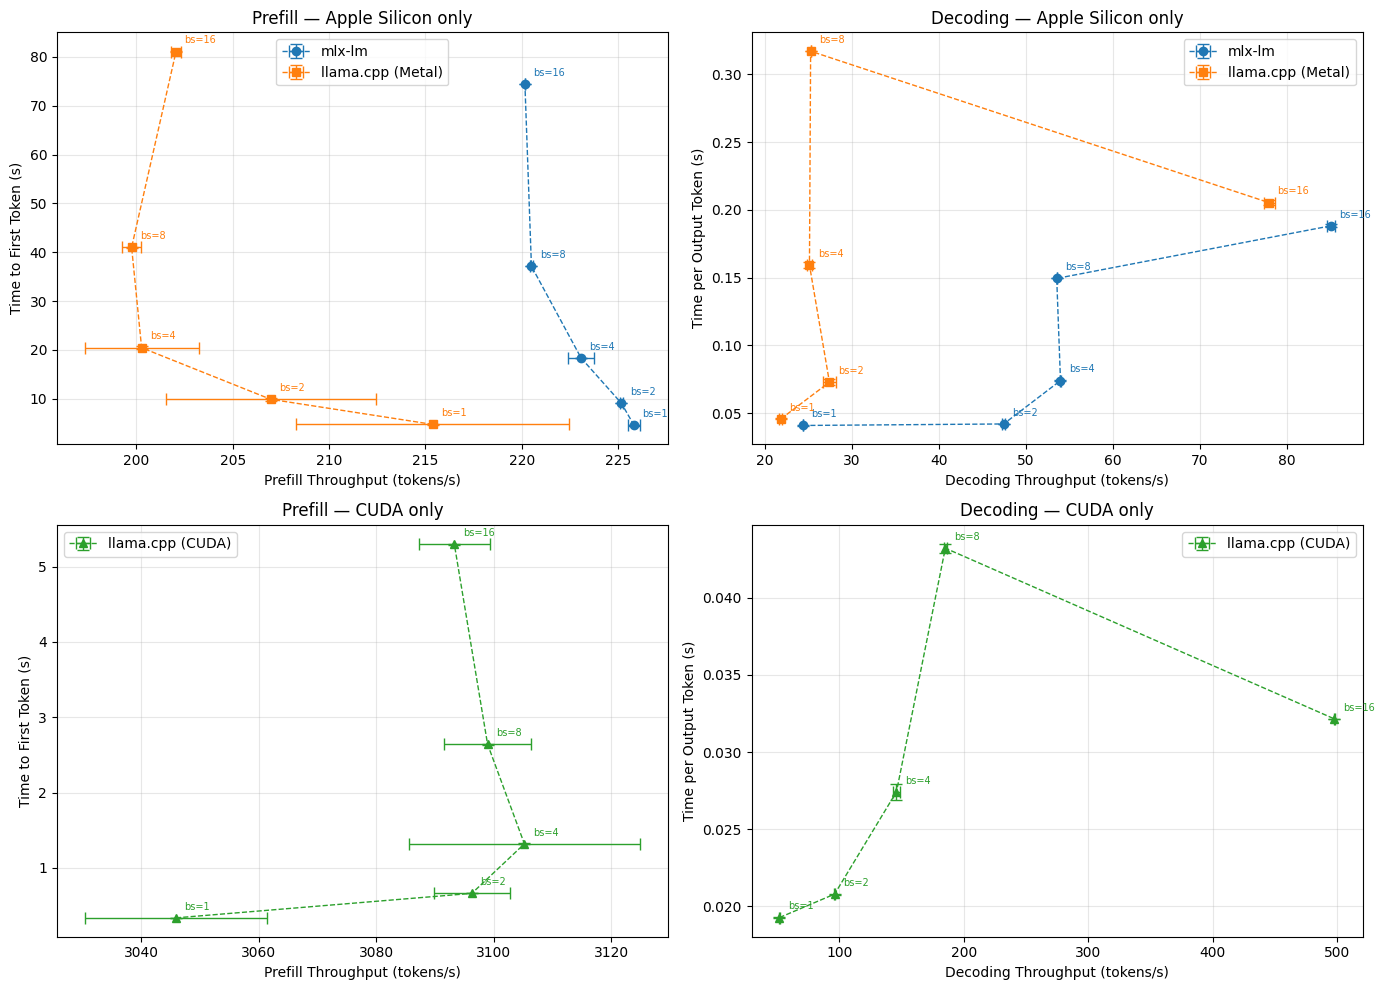

In [62]:
all_frameworks = {
    "mlx-lm": mlx_batch_results,
    "llama.cpp (Metal)": llama_metal_batch_results,
    "llama.cpp (CUDA)": llama_cuda_batch_results,
}
apple_frameworks = {k: v for k, v in all_frameworks.items() if k != "llama.cpp (CUDA)"}
cuda_frameworks = {"llama.cpp (CUDA)": llama_cuda_batch_results}

colors = {"mlx-lm": "tab:blue", "llama.cpp (Metal)": "tab:orange", "llama.cpp (CUDA)": "tab:green"}
markers = {"mlx-lm": "o", "llama.cpp (Metal)": "s", "llama.cpp (CUDA)": "^"}


def plot_prefill(ax, frameworks, log_scale=False):
    for name, results in frameworks.items():
        batch_sizes = sorted(results.keys())
        pp_tp_mean, pp_tp_std, ttft_mean, ttft_std = [], [], [], []
        for bs in batch_sizes:
            r = results[bs]
            mu, sigma = r.pp_tps_mean, r.pp_tps_std
            pp_tp_mean.append(mu)
            pp_tp_std.append(sigma)
            ttft_mean.append(r.pp_tokens * bs / mu)
            ttft_std.append(r.pp_tokens * bs * sigma / mu**2)
        ax.errorbar(pp_tp_mean, ttft_mean, xerr=pp_tp_std, yerr=ttft_std,
                    label=name, color=colors[name], marker=markers[name],
                    capsize=4, linestyle="--", linewidth=1)
        for bs, x, y in zip(batch_sizes, pp_tp_mean, ttft_mean):
            ax.annotate(f"bs={bs}", (x, y), textcoords="offset points",
                        xytext=(6, 6), fontsize=7, color=colors[name])
    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlabel("Prefill Throughput (tokens/s)")
    ax.set_ylabel("Time to First Token (s)")
    ax.legend()
    ax.grid(True, alpha=0.3)


def plot_generation(ax, frameworks, log_scale=False):
    for name, results in frameworks.items():
        batch_sizes = sorted(results.keys())
        gen_tp_mean, gen_tp_std, tpot_mean, tpot_std = [], [], [], []
        for bs in batch_sizes:
            r = results[bs]
            mu, sigma = r.gen_tps_mean, r.gen_tps_std
            gen_tp_mean.append(mu)
            gen_tp_std.append(sigma)
            tpot_mean.append(bs / mu)
            tpot_std.append(bs * sigma / mu**2)
        ax.errorbar(gen_tp_mean, tpot_mean, xerr=gen_tp_std, yerr=tpot_std,
                    label=name, color=colors[name], marker=markers[name],
                    capsize=4, linestyle="--", linewidth=1)
        for bs, x, y in zip(batch_sizes, gen_tp_mean, tpot_mean):
            ax.annotate(f"bs={bs}", (x, y), textcoords="offset points",
                        xytext=(6, 6), fontsize=7, color=colors[name])
    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlabel("Decoding Throughput (tokens/s)")
    ax.set_ylabel("Time per Output Token (s)")
    ax.legend()
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: Apple Silicon only (linear scale)
plot_prefill(axes[0, 0], apple_frameworks)
axes[0, 0].set_title("Prefill — Apple Silicon only")
plot_generation(axes[0, 1], apple_frameworks)
axes[0, 1].set_title("Decoding — Apple Silicon only")

# Bottom row: All frameworks (log scale)
# plot_prefill(axes[1, 0], all_frameworks, log_scale=True)
plot_prefill(axes[1, 0], cuda_frameworks)
axes[1, 0].set_title("Prefill — CUDA only")
# plot_generation(axes[1, 1], all_frameworks, log_scale=True)
plot_generation(axes[1, 1], cuda_frameworks)
axes[1, 1].set_title("Decoding — CUDA only")

plt.tight_layout()
plt.show()

### Conclusion
Across both sub-experiments, several consistent patterns emerge. On Apple Silicon, `mlx-lm` holds a meaningful advantage over `llama.cpp` for decode throughput at low bit-widths, though this advantage narrows at higher precision levels. In prefill, the two frameworks perform comparably. Neither framework scales well with batch size during prefill on Apple Silicon, reflecting the limited compute headroom available above batch size 1; however, `mlx-lm` scales more consistently across batch sizes for decode, whereas `llama.cpp` exhibits only abrupt, step-wise throughput gains at high batch sizes.

Compared to CUDA, Apple Silicon is at a significant disadvantage for prefill, driven primarily by the roughly 7x difference in raw FP16 compute (4.3 vs. 30.3 TFLOPS); however, Apple Silicon is considerably more competitive for decode, where the approximately 2.5x memory bandwidth ratio (120 vs. 300.1 GB/s) translates to a comparable ratio in decode throughput. This suggests that Apple Silicon is a viable platform for memory-bandwidth-bound inference workloads such as single-user chat, but falls well short of CUDA for compute-intensive tasks such as large-batch prefill.

Overall, `mlx-lm` is the stronger low-level inference engine on Apple Silicon, particularly at 4-bit quantisation and across a range of batch sizes.

## Experiment 2: Energy Benchmarks
Having investigated framework performance in terms of latency and throughput, we now turn to energy efficiency. This is particularly relevant for quantifying the cost efficiency of running LLM inference on consumer hardware and for understanding the environmental impact of different inference setups. The goal of this experiment is to compare the energy efficiency of the `mlx-lm` backend against the Metal backend of `llama.cpp` on Apple Silicon, and against CUDA-based inference on the cluster.

Energy usage is measured using Zeus [6], which monitors CPU, DRAM, and GPU energy consumption over a specified time window. Note that measuring CPU and DRAM energy requires root access on the cluster, which we were unable to obtain for this project. CUDA energy measurements on the cluster therefore exclude CPU and DRAM contributions; we examine the implications of this in the results discussion.

### Implementation
We begin by defining helper functions for measuring idle power, converting the `zeus.monitor.energy.Measurement` object into a unified `SystemMeasurement` struct, and computing net energy given an empirical estimate of the baseline idle load:

In [22]:
@dataclass
class SystemMeasurement:
    cpu: float | None = None
    gpu: float | None = None
    dram: float | None = None

@dataclass
class EnergyMeasurement:
    pp_tokens: int
    gen_tokens: int
    pp_time: float
    gen_time: float
    pp_j: SystemMeasurement
    gen_j: SystemMeasurement
    idle_power_w: SystemMeasurement

    @classmethod
    def from_dict(cls, data: dict) -> Self:
        pp_j = SystemMeasurement(**data.pop("pp_j", {}))
        gen_j = SystemMeasurement(**data.pop("gen_j", {}))
        idle_power_w = SystemMeasurement(**data.pop("idle_power_w", {}))
        return cls(**data, pp_j=pp_j, gen_j=gen_j, idle_power_w=idle_power_w)

def apple_silicon_metrics_to_joules(m: Measurement) -> SystemMeasurement:
    """Return (cpu_j, gpu_j, dram_j) from a Zeus Measurement (fields reported in mJ)."""
    soc_energy = m.soc_energy
    assert isinstance(soc_energy, AppleSiliconMeasurement)
    cpu_j = (soc_energy.cpu_total_mj or 0) / 1000.0
    gpu_j = (soc_energy.gpu_mj or 0) / 1000.0
    dram_j = (soc_energy.dram_mj or 0) / 1000.0
    return SystemMeasurement(cpu=cpu_j, gpu=gpu_j, dram=dram_j)


def measure_idle_power(monitor: ZeusMonitor) -> SystemMeasurement:
    """Measure mean idle power (W) per component over IDLE_SECONDS."""
    monitor.begin_window("idle")
    time.sleep(IDLE_SECONDS)
    m = monitor.end_window("idle")
    idle_j = apple_silicon_metrics_to_joules(m)
    return SystemMeasurement(
        cpu=(idle_j.cpu or 0) / IDLE_SECONDS,
        gpu=(idle_j.gpu or 0) / IDLE_SECONDS,
        dram=(idle_j.dram or 0) / IDLE_SECONDS,
    )


def net_energy_j(raw_j: float, idle_power_w: float, duration_s: float) -> float:
    """Subtract idle baseline energy from a measurement, clamped to 0."""
    return max(raw_j - idle_power_w * duration_s, 0.0)

Rather than using the `mlx-lm` and `llama.cpp` CLIs, this experiment uses their Python bindings, which allow for simpler integration within the Jupyter notebook. However, these bindings do not support prompt synthesis from a token count alone. We therefore generate synthetic prompts using the `faker` library: `Faker().sentence()` produces a plausible sentence, and the model's tokeniser is then used to trim it to the required length. The `Faker` instance is seeded to ensure that both inference engines receive identical input sequences across runs.

In [17]:
def generate_random_token_prompt(tokenizer, num_tokens: int, seed: int | None = None) -> list[int]:
    fake = Faker()
    if seed is not None:
        fake.seed_instance(seed)
    text_buffer = ""
    while len(text_buffer.split()) < 2 * num_tokens:
        text_buffer += fake.sentence() + " "
    tokens = tokenizer.encode(text_buffer)[:num_tokens]
    assert len(tokens) == num_tokens, f"Generated prompt has {len(tokens)} tokens, expected {num_tokens}"
    return tokens

The energy measurement function for `mlx-lm` proceeds as follows: at the start of each run, we measure the idle power load. A timer and a Zeus measurement window are opened simultaneously at the start of inference. We record time-to-first-token as the prefill duration, then open a second measurement window covering the remainder of the request to capture decode-phase energy.

In [24]:
def mlx_single_energy_inference(
    model,
    tokenizer,
    prompt: list[int] | str,
    monitor: ZeusMonitor,
) -> EnergyMeasurement:
    """Single mlx-lm inference with sequential prefill/generation energy windows."""
    idle_power = measure_idle_power(monitor)
    prefill_metrics = None
    gen_metrics = None
    first_token_time = None
    generation_end_time = None
    prompt_token_count = 0
    completion_tokens = 0

    monitor.begin_window("prefill")
    request_start = time.perf_counter()

    for resp in mlx_lm.stream_generate(model, tokenizer, prompt=prompt, max_tokens=GENERATION_TOKENS):
        if first_token_time is None:
            first_token_time = time.perf_counter()
            prefill_metrics = monitor.end_window("prefill")
            monitor.begin_window("generation")
            prompt_token_count = resp.prompt_tokens
        completion_tokens = resp.generation_tokens
        generation_end_time = time.perf_counter()

    if first_token_time is None:
        first_token_time = time.perf_counter()
        prefill_metrics = monitor.end_window("prefill")
        generation_end_time = first_token_time
        monitor.begin_window("generation")
        print("Warning: no tokens were generated, so generation energy will be 0", file=sys.stderr)

    gen_metrics = monitor.end_window("generation")

    pp_j = apple_silicon_metrics_to_joules(prefill_metrics)  # pyright: ignore[reportArgumentType]
    gen_j = apple_silicon_metrics_to_joules(gen_metrics)

    return EnergyMeasurement(
        pp_tokens=prompt_token_count,
        gen_tokens=completion_tokens,
        pp_time=first_token_time - request_start,
        gen_time=generation_end_time - first_token_time,  # pyright: ignore[reportOptionalOperand]
        pp_j=pp_j,
        gen_j=gen_j,
        idle_power_w=idle_power,
    )

Following the previously established protocol, we run one warmup and three measurement iterations, with a 30-second cooldown between runs to allow the hardware to return to idle thermal state:

In [ ]:
def run_mlx_energy_benchmark(quantization: Quantization) -> list[EnergyMeasurement]:
    monitor = ZeusMonitor()
    model, tokenizer, config = mlx_lm.load(quantization.to_mlx_model_name(), return_config=True)  # type: ignore[reportAssignmentType]

    # run warm ups
    for warmup_id in range(WARMUP_RUNS):
        prompt = generate_random_token_prompt(tokenizer=tokenizer, num_tokens=PROMPT_TOKENS, seed=-1 - warmup_id)
        mlx_single_energy_inference(model, tokenizer, prompt, monitor)

    measurements = []
    # run measurements
    for run_id in range(REPEAT_RUNS):
        prompt = generate_random_token_prompt(tokenizer=tokenizer, num_tokens=PROMPT_TOKENS, seed=run_id)
        time.sleep(APPLE_COOLDOWN_TIME)
        energy_measurement = mlx_single_energy_inference(model, tokenizer, prompt, monitor)
        measurements.append(energy_measurement)
    
    return measurements

mlx_energy_measurements = run_mlx_energy_benchmark(Quantization.INT4)

The `llama.cpp` variant of this benchmark is structurally identical, substituting the `mlx-lm` interface with the `llama_cpp.Llama` interface for inference:

In [26]:
def _llama_single_inference(
    llm: llama_cpp.Llama,
    prompt: str | list[int],
    prompt_tokens: int,
    monitor: ZeusMonitor,
) -> EnergyMeasurement:
    """Single llama-cpp inference with sequential prefill/generation energy windows.

    Returns:
        EnergyMeasurement
    """
    idle_power_w = measure_idle_power(monitor)
    prefill_metrics = None
    gen_metrics = None
    first_token_time = None
    generation_end_time = None
    output_chunks = []

    monitor.begin_window("prefill")
    request_start = time.perf_counter()

    for chunk in llm(prompt, max_tokens=GENERATION_TOKENS, temperature=0, stream=True):  # type: ignore[reportArgumentType]
        text = chunk["choices"][0]["text"]  # type: ignore[reportArgumentType]
        if not text:
            continue
        if first_token_time is None:
            first_token_time = time.perf_counter()
            prefill_metrics = monitor.end_window("prefill")
            monitor.begin_window("generation")
        output_chunks.append(text)
        generation_end_time = time.perf_counter()

    if first_token_time is None:
        # No tokens generated
        first_token_time = time.perf_counter()
        prefill_metrics = monitor.end_window("prefill")
        generation_end_time = first_token_time
        monitor.begin_window("generation")

    gen_metrics = monitor.end_window("generation")

    # Count completion tokens via llama-cpp's own tokenizer for accuracy
    full_output = "".join(output_chunks)
    completion_tokens = len(llm.tokenize(full_output.encode())) if full_output else 0

    return EnergyMeasurement(
        pp_tokens=prompt_tokens,
        gen_tokens=completion_tokens,
        pp_time=first_token_time - request_start,
        gen_time=generation_end_time - first_token_time, # type: ignore[reportOptionalOperand]
        pp_j=apple_silicon_metrics_to_joules(prefill_metrics),  # type: ignore
        gen_j=apple_silicon_metrics_to_joules(gen_metrics),
        idle_power_w=idle_power_w,
    )


def run_llama_metal_energy_benchmark(quantization: Quantization) -> list[EnergyMeasurement]:

    monitor = ZeusMonitor()

    llm = llama_cpp.Llama(quantization.to_ttuf_model_name(), n_gpu_layers=-1, verbose=False, n_ctx=PROMPT_TOKENS + GENERATION_TOKENS)
    
    for warmup_id in range(WARMUP_RUNS):
        # Count prompt tokens with llama-cpp's own tokenizer
        prompt = generate_random_token_prompt(tokenizer=llm.tokenizer(), num_tokens=PROMPT_TOKENS, seed=-1 - warmup_id)
        prompt_tokens = len(llm.tokenize(llm.detokenize(prompt)))
        _llama_single_inference(llm, prompt, prompt_tokens, monitor)

    measurements = []
    for run_id in range(REPEAT_RUNS):
        time.sleep(APPLE_COOLDOWN_TIME)
        prompt = generate_random_token_prompt(tokenizer=llm.tokenizer(), num_tokens=PROMPT_TOKENS, seed=run_id)
        prompt_tokens = len(llm.tokenize(llm.detokenize(prompt)))
        energy_measurement = _llama_single_inference(llm, prompt, prompt_tokens, monitor)
        measurements.append(energy_measurement)
    
    return measurements


In [ ]:
llama_metal_energy_measurements = run_llama_metal_energy_benchmark(Quantization.INT4)

An equivalent version of this benchmark, including all required helper functions, is stored on the remote machine at `run_llama_energy_benchmark.py`. Results are written in JSON Lines format:

In [ ]:
def run_llama_cuda_energy_benchmark(quantization: Quantization, cuda_device: int = 0) -> list[EnergyMeasurement]:
    # runs the same llama-cpp energy benchmark as for METAL, but on the remote cluster with CUDA, via ssh (paramiko)
    with paramiko.SSHClient() as ssh:
        ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        ssh.connect(REMOTE_HOST, username=REMOTE_USERNAME, key_filename=SSH_KEY_PATH)

        # We run a Python script on the remote machine that executes the energy benchmark and saves results to a file.
        params = [
            f"--quantization {quantization.name}",
            f"--idle-seconds {IDLE_SECONDS}",
            f"--warmup-runs {WARMUP_RUNS}",
            f"--repeat-runs {REPEAT_RUNS}",
            f"--prompt-tokens {PROMPT_TOKENS}",
            f"--generation-tokens {GENERATION_TOKENS}",
        ]
        cmd = f'cd {REMOTE_REPO_PATH} && CUDA_VISIBLE_DEVICES={cuda_device} uv run --extra cuda benchmarks/run_llama_energy_benchmark.py {" ".join(params)}'

        stdin, stdout, stderr = ssh.exec_command(f"zsh -l -c '{cmd}'")
        exit_status = stdout.channel.recv_exit_status()
        print(f"Remote command exited with status {exit_status}")
        if exit_status != 0:
            err = stderr.read().decode()
            print(f"Error running remote benchmark: {err}")
            return []
        
        # Retrieve the resulting energy benchmark file
        measurements = [
            EnergyMeasurement.from_dict(json.loads(line.strip()))
            for line in stdout
        ]

    return measurements


In [ ]:
llama_cuda_energy_measurements = run_llama_cuda_energy_benchmark(Quantization.INT4, cuda_device=REMOTE_CUDA_VISIBLE_DEVICES)

In [ ]:
all_energy = {
    "mlx-lm": mlx_energy_measurements,
    "llama.cpp (Metal)": llama_metal_energy_measurements,
    "llama.cpp (CUDA)": llama_cuda_energy_measurements,
}

colors = {"mlx-lm": "tab:blue", "llama.cpp (Metal)": "tab:orange", "llama.cpp (CUDA)": "tab:green"}
components = ["cpu", "gpu", "dram"]
component_labels = {"cpu": "CPU", "gpu": "GPU", "dram": "DRAM"}
component_colors = {"cpu": "#1f77b4", "gpu": "#ff7f0e", "dram": "#2ca02c"}

labels = list(all_energy.keys())
x = np.arange(len(labels))
bar_width = 0.5
bar_colors = [colors[l] for l in labels]

# Pre-compute per-component and total net J/token for each framework
pp_comp = {c: {} for c in components}
tg_comp = {c: {} for c in components}
idle_comp = {c: {} for c in components}
pp_total, tg_total, idle_total = {}, {}, {}

for label, measurements in all_energy.items():
    for comp in components:
        pp_jpt = [
            net_energy_j(getattr(m.pp_j, comp) or 0, getattr(m.idle_power_w, comp) or 0, m.pp_time) / m.pp_tokens
            for m in measurements
        ]
        tg_jpt = [
            net_energy_j(getattr(m.gen_j, comp) or 0, getattr(m.idle_power_w, comp) or 0, m.gen_time) / m.gen_tokens
            for m in measurements
        ]
        idle_w = [getattr(m.idle_power_w, comp) or 0 for m in measurements]
        pp_comp[comp][label] = (np.mean(pp_jpt), np.std(pp_jpt))
        tg_comp[comp][label] = (np.mean(tg_jpt), np.std(tg_jpt))
        idle_comp[comp][label] = (np.mean(idle_w), np.std(idle_w))

    pp_jpt_total = [sum(net_energy_j(getattr(m.pp_j, c) or 0, getattr(m.idle_power_w, c) or 0, m.pp_time) for c in components) / m.pp_tokens for m in measurements]
    tg_jpt_total = [sum(net_energy_j(getattr(m.gen_j, c) or 0, getattr(m.idle_power_w, c) or 0, m.gen_time) for c in components) / m.gen_tokens for m in measurements]
    idle_w_total = [sum(getattr(m.idle_power_w, c) or 0 for c in components) for m in measurements]
    pp_total[label] = (np.mean(pp_jpt_total), np.std(pp_jpt_total))
    tg_total[label] = (np.mean(tg_jpt_total), np.std(tg_jpt_total))
    idle_total[label] = (np.mean(idle_w_total), np.std(idle_w_total))

### Results and Discussion

Results are shown below.

The top row shows net energy consumption during the prefill and decode phases, with idle energy subtracted from total energy to isolate the incremental cost of inference. For both phases, `mlx-lm` is meaningfully more energy-efficient than `llama.cpp` on Apple Silicon, consuming approximately 10% less energy during prefill and 25% less during decode, confirming that the optimisations in `mlx-lm` translate to tangible energy savings as well as throughput gains.

Comparing these values to the CUDA backend reveals a striking asymmetry. During prefill, the L4 GPU is substantially more energy-efficient per token than `mlx-lm` on Apple Silicon by a factor of approximately 9x. During decode, however, the picture reverses: CUDA is around 50% less efficient than `mlx-lm` and around 10% less efficient than `llama.cpp` on Apple Silicon. This reversal has an outsized impact on total inference energy cost, since the decode phase dominates overall consumption: energy per token during decode is an order of magnitude higher than during prefill.

A key caveat is that a high-powered CUDA GPU carries a substantial idle power draw (25W vs. approximately 0W for Apple Silicon), which adds to the operational energy cost even when no inference is being performed. As shown in the bottom row, accounting for idle power shifts both comparisons further in Apple Silicon's favour: the energy advantage of CUDA during prefill narrows from approximately 9x to around 4x, while Apple Silicon's advantage during decode grows from 50% to around 150%.

Note also that the cluster measurements exclude CPU and DRAM energy due to lack of root access. Assuming these components contribute proportionally to total energy consumption as they do on Apple Silicon, this would increase the effective energy cost of CUDA inference by a further 10% for prefill and 25–30% for decode.

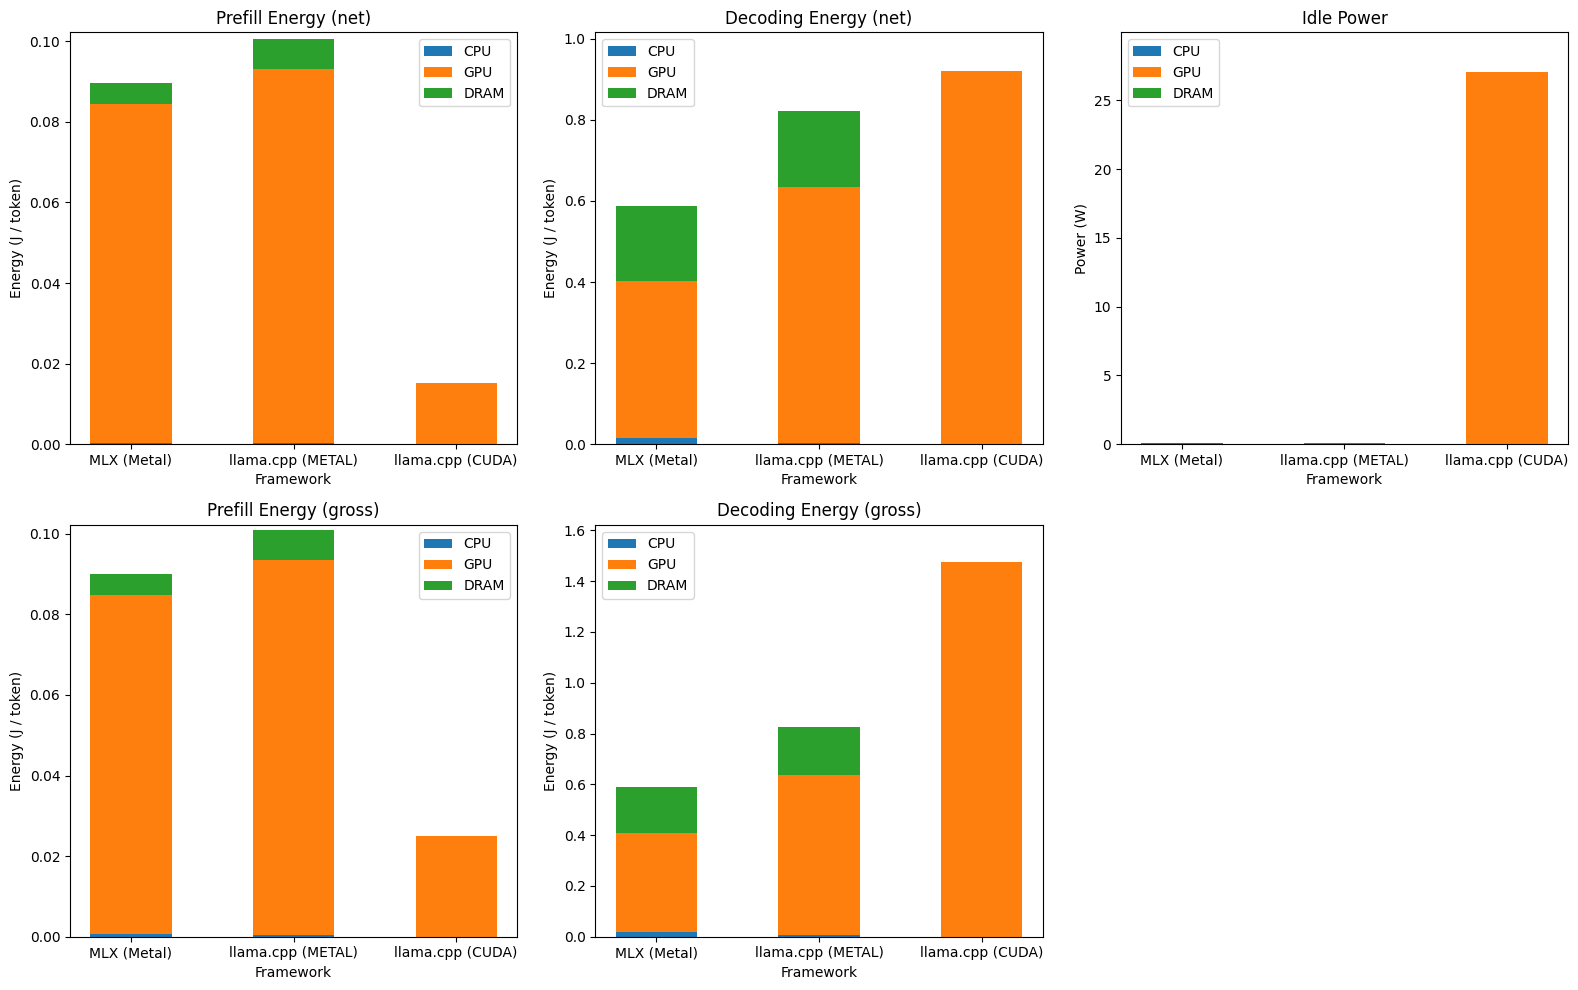

In [66]:
# Stacked bar: per-component energy breakdown

# Compute gross (idle-inclusive) J/token
pp_comp_gross = {c: {} for c in components}
tg_comp_gross = {c: {} for c in components}

for label, measurements in all_energy.items():
    for comp in components:
        pp_jpt = [
            (getattr(m.pp_j, comp) or 0) / m.pp_tokens
            for m in measurements
        ]
        tg_jpt = [
            (getattr(m.gen_j, comp) or 0) / m.gen_tokens
            for m in measurements
        ]
        pp_comp_gross[comp][label] = (np.mean(pp_jpt), np.std(pp_jpt))
        tg_comp_gross[comp][label] = (np.mean(tg_jpt), np.std(tg_jpt))

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=False)

# Top row: net energy (idle subtracted)
for ax, title, data in [
    (axes[0, 0], "Prefill Energy (net)", pp_comp),
    (axes[0, 1], "Decoding Energy (net)", tg_comp),
    (axes[0, 2], "Idle Power", idle_comp),
]:
    bottom = np.zeros(len(labels))
    for comp in components:
        means = np.array([data[comp][l][0] for l in labels])
        ax.bar(x, means, bar_width, bottom=bottom, label=component_labels[comp],
               color=component_colors[comp])
        bottom += means
    ax.set_xlabel("Framework")
    ax.set_ylabel("Energy (J / token)" if "Idle" not in title else "Power (W)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_ylim(0, 1.1 * max(data[comp][l][0] + data[comp][l][1] for comp in components for l in labels))
    ax.set_xticklabels(labels)
    ax.legend()

# Bottom row: gross energy (idle inclusive)
for ax, title, data in [
    (axes[1, 0], "Prefill Energy (gross)", pp_comp_gross),
    (axes[1, 1], "Decoding Energy (gross)", tg_comp_gross),
]:
    bottom = np.zeros(len(labels))
    for comp in components:
        means = np.array([data[comp][l][0] for l in labels])
        ax.bar(x, means, bar_width, bottom=bottom, label=component_labels[comp],
               color=component_colors[comp])
        bottom += means
    ax.set_xlabel("Framework")
    ax.set_ylabel("Energy (J / token)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_ylim(0, 1.1 * max(data[comp][l][0] + data[comp][l][1] for comp in components for l in labels))
    ax.set_xticklabels(labels)
    ax.legend()

axes[1, 2].set_visible(False)

fig.tight_layout()
plt.show()

### Implications on Operational Cost

Although CUDA's substantially lower energy consumption during prefill might suggest lower operational costs overall, the higher energy cost during decode largely negates this effect. To illustrate, we present a simple cost comparison assuming retail hardware prices of approximately [£1,299](https://www.apple.com/uk/shop/buy-mac/macbook-air) for the MacBook Air M4$^1$ and [£2,519](https://www.novatech.co.uk/products/pny-nvidia-l4-24gb-gddr6-data-centre-gpu/tcsl4pcie-pb.html) for the NVIDIA L4 GPU $^2$, a hardware lifetime of three years, an electricity price of [£0.27 per kWh](https://energysavingtrust.org.uk/average-uk-energy-bill/) an average inference workload of 100,000,000 tokens per day (roughly half the token usage [some CEOs have set as targets for their software engineers](https://www.businessinsider.com/jensen-huang-500k-engineers-250k-ai-tokens-nvidia-compute-2026-3)). The plot below shows daily operational cost as a function of prefill-to-decode ratio:

---

$^1$: As Apple no longer lists the M4 MacBook Air on their website, we use the M5 MacBook Air price as a proxy; launch prices for the two generations were comparable.

$^2$: This is the GPU-only price; a complete CUDA-based inference setup would incur additional hardware costs, which we exclude here for simplicity. This assumption favours the CUDA setup in our calculation.

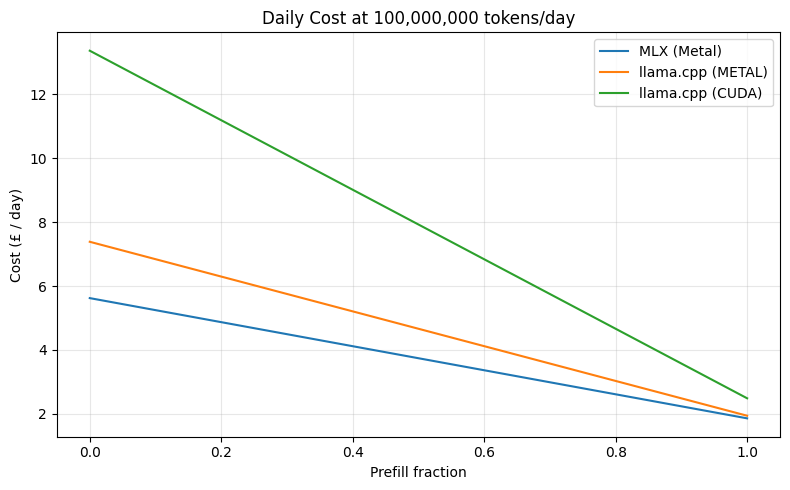

In [109]:
FIXED_TOKENS_PER_DAY = 100_000_000
MACBOOK_PRICE = 1_299.00
L4_PRICE = 2_519.99
ELECTRICITY_PRICE_PER_KWH = 0.27  # £/kWh (UK average)
HARDWARE_LIFETIME_DAYS = 3 * 365
J_PER_KWH = 3_600_000

# Gross total J/token for each framework (idle-inclusive)
pp_gross_total = {}
tg_gross_total = {}
for label, measurements in all_energy.items():
    pp_jpt = [sum((getattr(m.pp_j, c) or 0) for c in components) / m.pp_tokens for m in measurements]
    tg_jpt = [sum((getattr(m.gen_j, c) or 0) for c in components) / m.gen_tokens for m in measurements]
    pp_gross_total[label] = np.mean(pp_jpt)
    tg_gross_total[label] = np.mean(tg_jpt)

prefill_frac = np.linspace(0, 1, 500)

# Hardware amortisation per day
hw_cost = {
    "MLX (Metal)": MACBOOK_PRICE / HARDWARE_LIFETIME_DAYS,
    "llama.cpp (METAL)": MACBOOK_PRICE / HARDWARE_LIFETIME_DAYS,
    "llama.cpp (CUDA)": L4_PRICE / HARDWARE_LIFETIME_DAYS,
}


fig, ax = plt.subplots(figsize=(8, 5))

for label in labels:
    j_per_token = prefill_frac * pp_gross_total[label] + (1 - prefill_frac) * tg_gross_total[label]
    energy_cost = FIXED_TOKENS_PER_DAY * j_per_token / J_PER_KWH * ELECTRICITY_PRICE_PER_KWH
    total_cost = hw_cost[label] + energy_cost
    ax.plot(prefill_frac, total_cost, label=label, color=colors[label])

ax.set_xlabel("Prefill fraction")
ax.set_ylabel("Cost (£ / day)")
ax.set_title(f"Daily Cost at {FIXED_TOKENS_PER_DAY:,} tokens/day")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

Apple Silicon inference proves more cost-efficient across the full range of prefill-to-decode ratios, including the extreme and unrealistic case of 100% prefill with no decoding. For more realistic workload compositions, the cost gap widens considerably: at a 50% prefill ratio, Apple Silicon is approximately 2x more cost-efficient, rising to around 3x at a 10% prefill ratio (assuming `mlx-lm`).

This advantage would only increase at lower, more realistic token volumes, reinforcing the case for Apple Silicon as a cost-effective platform for consumer-hosted LLM inference, particularly for decode-heavy workloads. This comes at the cost of lower throughput, as demonstrated in Experiment 1, which remains a critical consideration for latency-sensitive applications.

## Experiment 3: Higher-Level Serving Engine Benchmark (`oMLX` vs `Ollama`)

In practice, LLM inference is rarely invoked directly via a low-level engine API. Instead, it is typically exposed through a higher-level serving layer that provides quality-of-life features such as simplified setup, request routing and batching, model and conversation management, and a wider range of deployment interfaces.

This experiment evaluates two such serving layers: `**oMLX**` (built on `mlx-lm`) and `**Ollama**` (built on `llama.cpp`), with the aim of answering the following two questions:
- How much **performance overhead** does the serving layer introduce relative to the raw engine?
- How well do the engines handle **multi-conversation settings**, in which a user switches between multiple conversation contexts?

Although many other aspects of a serving layer are relevant to user experience and could in principle be benchmarked (such as model loading time or API latency under varying load) we restrict our analysis to these two questions. The second is of particular interest because `oMLX` and `Ollama` adopt different strategies for managing multi-conversation contexts and the associated KV cache growth, and we wish to understand the implications of these design choices for user experience.

Unlike the low-level frameworks, `oMLX` and `Ollama` both require a running server to handle inference requests. Our benchmarks must therefore manage server setup and teardown, handled by the following helper functions:

In [55]:
@dataclass
class ServerHandle:
    process: asyncio.subprocess.Process
    url: str
    pid: int
    server_cmd: str | list[str]
    model: str = ""


async def poll_health(url: str, timeout: float = 20):
    """Block until the server responds 200 at *url*, or raise after *timeout* seconds."""
    deadline = time.monotonic() + timeout
    while time.monotonic() < deadline:
        try:
            async with aiohttp.ClientSession(timeout=aiohttp.ClientTimeout(total=5)) as s:
                async with s.get(url) as r:
                    if r.status == 200:
                        return
        except Exception:
            pass
        await asyncio.sleep(1)
    raise TimeoutError(f"Server did not become healthy at {url} within {timeout}s")


async def start_server(server_cmd: str | list[str], model: str, port: int, **env: str) -> ServerHandle:
    """Start the serving framework asynchronously, wait for health, and return a handle."""
    if isinstance(server_cmd, str):
        server_cmd = server_cmd.split()
    proc = await asyncio.create_subprocess_exec(
        *server_cmd,
        stdout=asyncio.subprocess.DEVNULL,
        stderr=asyncio.subprocess.DEVNULL,
        env={**os.environ.copy(), **env},
    )

    url = f"http://localhost:{port}/v1/chat/completions"
    health_url = f"http://localhost:{port}/v1/models"
    handle = ServerHandle(process=proc, url=url, pid=proc.pid, server_cmd=server_cmd, model=model)
    await poll_health(health_url)
    return handle


async def stop_server(handle: ServerHandle):
    """SIGTERM → wait 5s → SIGKILL."""
    proc = handle.process
    if proc.returncode is not None:
        return
    proc.send_signal(signal.SIGTERM)
    try:
        await asyncio.wait_for(proc.wait(), timeout=5.0)
    except asyncio.TimeoutError:
        proc.kill()
        await proc.wait()


@asynccontextmanager
async def run_server(server_cmd: str | list[str], model: str, port: int, **env: str):
    """Context manager for start_server + stop_server."""
    handle = await start_server(server_cmd, model, port, **env)
    try:
        yield handle
    finally:
        await stop_server(handle)

The benchmarks also require a client for sending inference requests and measuring latency and throughput. We implement a lightweight asynchronous client using `aiohttp` that follows the [OpenAI API conventions](https://developers.openai.com/api/reference/overview) and records the relevant metrics:

In [56]:
@dataclass
class RequestResult:
    ttft_ms: float = float("nan")
    generation_time_s: float = float("nan")
    prompt_tokens: int = 0
    completion_tokens: int = 0
    content: str = ""
    error: str | None = None


async def streaming_request(url: str, payload: dict, timeout_s: float = 600) -> RequestResult:
    if "stream_options" not in payload:
        payload["stream_options"] = {"include_usage": True}

    result = RequestResult()
    t_start = time.perf_counter()
    t_first = None

    try:
        timeout = aiohttp.ClientTimeout(total=timeout_s)
        async with aiohttp.ClientSession(timeout=timeout) as session:
            async with session.post(
                url,
                json=payload,
                headers={"Content-Type": "application/json"},
            ) as resp:
                if resp.status != 200:
                    body = await resp.text()
                    result.error = f"HTTP {resp.status}: {body[:500]}"
                    return result

                async for line in resp.content:
                    if not line:
                        continue

                    decoded_line = line.decode("utf-8", errors="replace")
                    if decoded_line == "data: [DONE]":
                        break

                    if not decoded_line.startswith("data: "):
                        continue

                    data_str = decoded_line[6:].strip()
                    if not data_str or data_str == "[DONE]":
                        continue
                        
                    try:
                        data = json.loads(data_str)
                    except json.JSONDecodeError:
                        continue

                    # Extract exact hardware token counts from the final usage chunk
                    if "usage" in data and data["usage"] is not None:
                        result.prompt_tokens = data["usage"].get("prompt_tokens", 0)
                        result.completion_tokens = data["usage"].get("completion_tokens", result.completion_tokens)

                    # Extract content if present
                    choices = data.get("choices", [])
                    if choices:
                        delta = choices[0].get("delta", {})
                        token_text = delta.get("content")
                        if token_text:
                            # Capture TTFT on the first valid JSON payload
                            if t_first is None:
                                t_first = time.perf_counter()
                                result.ttft_ms = (t_first - t_start) * 1000
                            result.content += token_text
                            

    except Exception as exc:
        result.error = str(exc)
        return result

    t_end = time.perf_counter()
    if t_first is not None:
        result.generation_time_s = t_end - t_first
    return result

def build_payload(*history: dict[str, str], max_tokens: int, model: str) -> dict:
    messages = list(history)
    return {
        "messages": messages,
        "max_tokens": max_tokens,
        "temperature": 0.0,
        "top_p": 1.0,
        "stream": True,
        "model": model,
    }

Two additional helper functions are required to compensate for capabilities provided by the low-level frameworks but absent in the serving layers. First, since the serving layers do not support guaranteed output length (generation stops automatically upon the end-of-sequence token), we implement a prompt generation function that produces syntactically valid prompts designed to suppress early stopping (e.g. by instructing the model to count incrementally to 100,000), ensuring that generation runs to the specified maximum length. Second, we implement a warmup function that sends a request with a specified number of system, input, and output tokens to prime the server and ensure the model is fully loaded before benchmark runs begin:

In [6]:
def generate_controlled_prompt(tokenizer, run_id: int, cycle: int, agent_id: str, target_tokens: int) -> str:
    prefix_text = f"UID:{run_id}-{cycle}-{agent_id}\n"
    prefix_tokens = tokenizer.encode(prefix_text, add_special_tokens=False)

    suffix_text = "\nTask: Count incrementally from 1 to 100,000. Do not stop. Do not provide commentary. Begin now: 1, 2, 3, 4, 5, 6, 7,"
    suffix_tokens = tokenizer.encode(suffix_text, add_special_tokens=False)

    required_padding = target_tokens - len(prefix_tokens) - len(suffix_tokens)
    if required_padding < 0:
        raise ValueError(f"Target token count ({target_tokens}) is insufficient to hold the control blocks.")

    padding_base_tokens = tokenizer.encode("system diagnostic routine running ", add_special_tokens=False)
    padding_tokens = []
    while len(padding_tokens) < required_padding:
        padding_tokens.extend(padding_base_tokens)
    padding_tokens = padding_tokens[:required_padding]

    final_tokens = prefix_tokens + padding_tokens + suffix_tokens
    assert len(final_tokens) == target_tokens
    return tokenizer.decode(final_tokens)

async def run_warmup(handle: ServerHandle, tokenizer: AutoTokenizer, num_system_tokens: int, num_input_tokens: int, num_output_tokens: int):
    system_prompt = tokenizer.decode(generate_random_token_prompt(tokenizer=tokenizer, num_tokens=num_system_tokens, seed=42))
    user_prompt = tokenizer.decode(generate_random_token_prompt(tokenizer=tokenizer, num_tokens=num_input_tokens, seed=43))
    payload = build_payload({"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}, max_tokens=num_output_tokens, model=handle.model)
    r = await streaming_request(handle.url, payload)
    if r.error:
        raise RuntimeError(f"Warm-up failed: {r.error}")

Finally, note that neither serving layer exposes a mechanism for explicitly clearing the KV cache, meaning the cache grows monotonically across runs and will eventually exhaust available memory. We therefore restart the server before each measurement run to reset the cache, and perform a warmup run after each restart to ensure the model is in a steady loaded state before measurements are taken.

### Experiment 3a: Measuring Performance Overhead of Higher-Level Serving Engines

Higher-level serving engines introduce additional latency on top of the raw inference engine, arising from sources such as HTTP request parsing, model management logic, and similar; the goal of this experiment is to isolate and quantify this overhead by comparing prefill and decode throughput measured via the HTTP API (`oMLX` / `Ollama`) against the equivalent measurements taken directly against the low-level engine (`mlx-lm` / `llama.cpp`) in Experiment 1.

We adopt a single-client, single-conversation setting (batch size 1) and use the same model (Qwen2.5-7B, 4-bit quantisation) as in Experiment 1, ensuring that any observed throughput difference is attributable to serving-layer overhead rather than concurrency effects. As in Experiment 1, we report prefill throughput (tokens/s) and decode throughput (tokens/s).

In [8]:
TOKENIZER_7B = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")

async def evaluate_framework_throughput(handle: ServerHandle) -> BenchmarkResults:
    print("Running warm-up cycles...")
    await run_warmup(handle, tokenizer=TOKENIZER_7B, num_system_tokens=WARMUP_SYSTEM_PROMPT_TOKENS, num_input_tokens=WARMUP_INPUT_TOKENS, num_output_tokens=WARMUP_OUTPUT_TOKENS)

    system_prompt = "You are a counting algorithm. You do not output text. You only output sequential integers, one per line."

    user_msgs = [
        generate_controlled_prompt(tokenizer=TOKENIZER_7B, run_id=run, cycle=0, agent_id="0", target_tokens=PROMPT_TOKENS)
        for run in range(REPEAT_RUNS)
    ]

    results = []

    n_tokens = []
    for message in user_msgs:
        time.sleep(APPLE_COOLDOWN_TIME)
        payload = build_payload({"role": "system", "content": system_prompt}, {"role": "user", "content": message}, max_tokens=GENERATION_TOKENS, model=handle.model)
        r = await streaming_request(handle.url, payload)
        if r.error:
            raise RuntimeError(f"Warm-up message failed: {r.error}")

        pp_tps = r.prompt_tokens / (r.ttft_ms / 1000) if r.ttft_ms > 0 else float("nan")
        gen_tps = r.completion_tokens / r.generation_time_s if r.generation_time_s > 0 else float("nan")
        results.append((pp_tps, gen_tps))
        n_tokens.append((r.prompt_tokens, r.completion_tokens))

    assert all(n == n_tokens[0] for n in n_tokens), f"Token counts varied across runs: {n_tokens}"

    return BenchmarkResults(
        pp_tps_mean=statistics.mean(pp for pp, _ in results),
        pp_tps_std=statistics.stdev(pp for pp, _ in results) if len(results) > 1 else 0.0,
        gen_tps_mean=statistics.mean(gen for _, gen in results),
        gen_tps_std=statistics.stdev(gen for _, gen in results) if len(results) > 1 else 0.0,
        pp_tokens=n_tokens[0][0],
        gen_tokens=n_tokens[0][1],
        batch_size=1,
    )

Each serving engine is started via its CLI in a subprocess; requests are sent asynchronously via HTTP using aiohttp. Since `oMLX` persists conversation histories and KV caches to disk, we clear the `oMLX` cache before each run to ensure a clean state:

In [15]:
import shutil

async def evaluate_omlx_throughput(quantization: Quantization) -> BenchmarkResults:
    # delete omlx cache directory to ensure clean benchmarking (no caching effects)
    cache_dir = os.path.expanduser("~/.omlx/cache")
    if os.path.exists(cache_dir):
        print(f"Clearing OMLX cache directory at {cache_dir} for clean benchmarking...")
        shutil.rmtree(cache_dir)
    async with run_server("omlx serve --model-dir ~/.omlx/models", model=quantization.to_mlx_model_name(), port=OMLX_DEFAULT_PORT) as handle:
        return await evaluate_framework_throughput(handle)

In [ ]:
omlx_throughput = await evaluate_omlx_throughput(Quantization.INT4)

The procedure for `Ollama` is analogous:

In [47]:
async def evaluate_ollama_metal_throughput(quantization: Quantization) -> BenchmarkResults:
    # env = {"OLLAMA_BACKEND": "metal"}
    async with run_server("ollama serve", model=quantization.to_ollama_model_name(), port=OLLAMA_DEFAULT_PORT ) as handle:
        return await evaluate_framework_throughput(handle)

In [ ]:
ollama_metal_throughput = await evaluate_ollama_metal_throughput(Quantization.INT4)

As in previous experiments, a self-contained benchmark script, equivalent to the notebook code, is stored on the remote machine at `run_ollama_benchmark.py`. Results are written as JSON Lines:

In [52]:
def evaluate_ollama_cuda_throughput(quantization: Quantization, cuda_device: int = 0) -> BenchmarkResults:
    # runs the same throughput benchmark as for METAL on the remote cluster with CUDA, via ssh (paramiko)
    with paramiko.SSHClient() as ssh:
        ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        ssh.connect(REMOTE_HOST, username=REMOTE_USERNAME, key_filename=SSH_KEY_PATH)

        params = [
            f"--quantization {quantization.name}",
            f"--repeat-runs {REPEAT_RUNS}",
            f"--prompt-tokens {PROMPT_TOKENS}",
            f"--generation-tokens {GENERATION_TOKENS}",
            f"--warmup-system-prompt-tokens {WARMUP_SYSTEM_PROMPT_TOKENS}",
            f"--warmup-input-tokens {WARMUP_INPUT_TOKENS}",
            f"--warmup-output-tokens {WARMUP_OUTPUT_TOKENS}",
        ]

        cmd = f'cd {REMOTE_REPO_PATH} && CUDA_VISIBLE_DEVICES={cuda_device} uv run --extra cuda benchmarks/run_ollama_throughput_benchmark.py {" ".join(params)}'
        stdin, stdout, stderr = ssh.exec_command(f"zsh -l -c '{cmd}'")
        exit_status = stdout.channel.recv_exit_status()
        print(f"Remote command exited with status {exit_status}")
        if exit_status != 0:
            err = stderr.read().decode()
            print(f"Error running remote benchmark: {err}")
            raise RuntimeError(f"Remote benchmark failed with status {exit_status}. Command: {cmd}")
        
        data = json.load(stdout)
        return BenchmarkResults.from_dict(data)

In [ ]:
ollama_cuda_benchmark_result = evaluate_ollama_cuda_throughput(Quantization.INT4, cuda_device=REMOTE_CUDA_VISIBLE_DEVICES)

#### Results

Results are shown below, alongside the raw engine benchmarks from Experiment 1 for direct comparison of serving-layer overhead.

The general trends from Experiment 1 are preserved: prefill throughput is broadly comparable between `oMLX` and `Ollama` on Apple Silicon, `oMLX` maintains a modest decode throughput advantage, and both trail the CUDA backend substantially. On Apple Silicon, serving-layer overhead is negligible for both frameworks and both phases; absolute throughput is closely matched between the high-level and low-level results.

The picture is notably different for CUDA, however, where `Ollama` shows a significant throughput reduction relative to raw `llama.cpp`: approximately 50% of `llama.cpp`'s prefill throughput and around 80% of its decode throughput. This suggests that the serving-layer overhead of `Ollama` is considerably more pronounced on CUDA than on Apple Silicon. A plausible explanation lies in Apple Silicon's unified memory architecture, which eliminates explicit data transfers between host and device memory. On a CUDA system, the serving layer may introduce additional overhead through more frequent CPU–GPU synchronisation and more complex memory management (for example, around KV cache handling or model state) which could account for the larger throughput gap observed between `Ollama` and raw `llama.cpp` on CUDA.

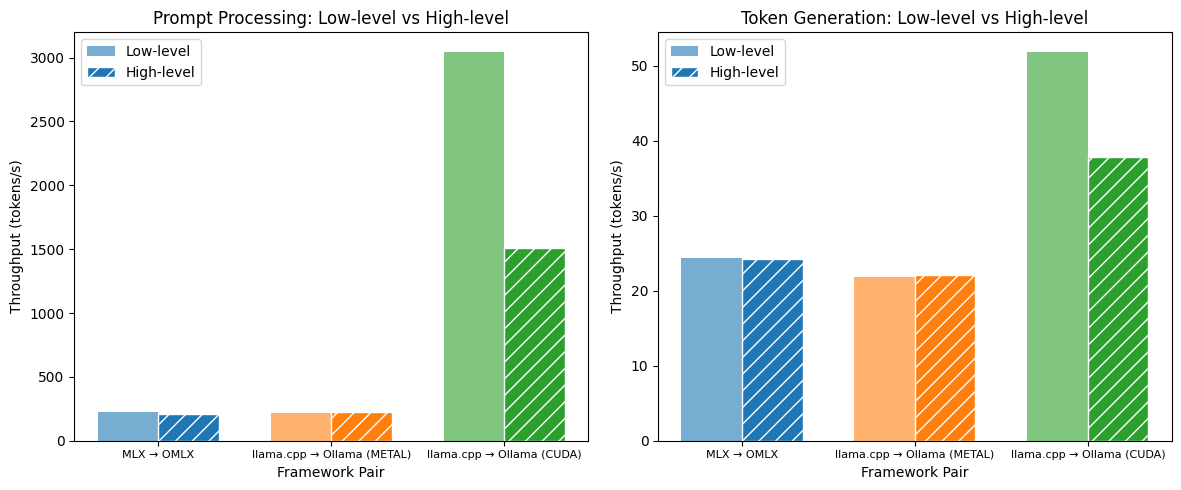

In [111]:
# Plot overhead: high-level vs low-level (bs=1)
pairs = [
    ("MLX → OMLX", mlx_batch_results[1], omlx_throughput, "tab:blue"),
    ("llama.cpp → Ollama (METAL)", llama_metal_batch_results[1], ollama_metal_throughput, "tab:orange"),
    ("llama.cpp → Ollama (CUDA)", llama_cuda_batch_results[1], ollama_cuda_benchmark_result, "tab:green"),
]

pair_labels = [p[0] for p in pairs]
x_pairs = np.arange(len(pair_labels))
bar_w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PP overhead
ll_pp = [p[1].pp_tps_mean for p in pairs]
hl_pp = [p[2].pp_tps_mean for p in pairs]
axes[0].bar(x_pairs - bar_w / 2, ll_pp, bar_w, label="Low-level", color=[p[3] for p in pairs], alpha=0.6)
axes[0].bar(x_pairs + bar_w / 2, hl_pp, bar_w, label="High-level", color=[p[3] for p in pairs], alpha=1.0,
            hatch="//", edgecolor="white")
axes[0].set_xlabel("Framework Pair")
axes[0].set_ylabel("Throughput (tokens/s)")
axes[0].set_title("Prompt Processing: Low-level vs High-level")
axes[0].set_xticks(x_pairs)
axes[0].set_xticklabels(pair_labels, fontsize=8)
axes[0].legend()

# Gen overhead
ll_gen = [p[1].gen_tps_mean for p in pairs]
hl_gen = [p[2].gen_tps_mean for p in pairs]
axes[1].bar(x_pairs - bar_w / 2, ll_gen, bar_w, label="Low-level", color=[p[3] for p in pairs], alpha=0.6)
axes[1].bar(x_pairs + bar_w / 2, hl_gen, bar_w, label="High-level", color=[p[3] for p in pairs], alpha=1.0,
            hatch="//", edgecolor="white")
axes[1].set_xlabel("Framework Pair")
axes[1].set_ylabel("Throughput (tokens/s)")
axes[1].set_title("Token Generation: Low-level vs High-level")
axes[1].set_xticks(x_pairs)
axes[1].set_xticklabels(pair_labels, fontsize=8)
axes[1].legend()

fig.tight_layout()
plt.show()

### Experiment 3b: Measuring Usability of Multi-Conversation Settings

While a single user rarely would send multiple requests at once, it is common for users to have multiple conversations with the same model, and switch between them. Conversation management is therefore an important aspect of LLM serving frameworks, as it has a significant impact on user experience. In that regard, `oMLX` employs a novel approach of a dynamic and tiered KV-cache, which allows for dynamically increasing the KV-cache size and intelligently persisting it to disk when it exceeds the available RAM; `Ollama`, on the other hand, relies on static KV-cache allocation, and does not willingly persist the KV-cache to disk; it relies on recomputation or KV eviction instead. This means that `oMLX` can potentially handle more and/or longer conversations without running into memory issues, KV recomputations or context loss, but it also introduces additional overhead for managing the KV-cache and persisting it to disk.

We therefore investigate the performance implications of these approach by simulating a multi-conversation setting, in which we have 4 parallel conversations with the model, and cycle through them for a total of 5 turns. We then measure the latency and throughput for each request, and compare it to the previous single-conversation setting. To reach the memory limits of the system, we use a larger model (Qwen2.5-14B) for this experiment, which occupies 7.7GB of RAM in 4-bit quantization; over the course of the multi-conversation benchmark, each conversation sends 5 requests with 128 input tokens and 128 output tokens, which means that the total number of tokens processed in this benchmark is 1024 (system prompt) + 4 (conversations) * 10 (turns) * (1024 (input) + 128 (output)) = 47104 tokens, which is large enough too exceed system memory and should be sufficient to trigger the dynamic KV-cache management of `oMLX` and observe latency degradations for `Ollama`.

In [ ]:
TOKENIZER_14B = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-14B-Instruct")

type Agent = str
type Cycle = int

@dataclass
class ConversationTurnResult:
    ttft_s: float
    gen_tps: float
    pp_token: int
    gen_tokens: int
    disk_read_mb: int
    disk_write_mb: int
    swap_used_mb: int
    # for Apple Silicon only
    peak_memory_mb: int = 0
    # used for CUDA only
    peak_vram_mb: int = 0
    host_ram_mb: int = 0

    @classmethod
    def from_dict(cls, data: dict) -> Self:
        return cls(**data)


@dataclass
class ConversationCycleResult:
    agent_results: dict[Agent, ConversationTurnResult]

    @classmethod
    def from_dict(cls, data: dict) -> Self:
        agent_results = {agent: ConversationTurnResult.from_dict(res) for agent, res in data["agent_results"].items()}
        return cls(agent_results=agent_results)


@dataclass
class ConversationRunResult:
    cycle_results: list[ConversationCycleResult]

    @classmethod
    def from_dict(cls, data: dict) -> Self:
        cycle_results = [ConversationCycleResult.from_dict(cycle) for cycle in data["cycle_results"]]
        return cls(cycle_results=cycle_results)


async def run_multi_conversation_run(handle: ServerHandle, run_id: int) -> ConversationRunResult:
    await run_warmup(handle, tokenizer=TOKENIZER_14B, num_system_tokens=WARMUP_SYSTEM_PROMPT_TOKENS, num_input_tokens=WARMUP_INPUT_TOKENS, num_output_tokens=WARMUP_OUTPUT_TOKENS)

    system_prompt = "You are a counting algorithm. You do not output text. You only output sequential integers, one per line."

    user_msgs = {
        (cycle, agent): generate_controlled_prompt(tokenizer=TOKENIZER_14B, run_id=run_id, cycle=cycle, agent_id=agent, target_tokens=USER_MSG_TOKENS)
        for cycle in range(1, NUM_CYCLES + 1) for agent in AGENTS
    }

    try:
        server_process = psutil.Process(handle.pid)
    except psutil.NoSuchProcess:
        raise RuntimeError(f"Server PID {handle.pid} not found.")

    histories: dict[str, list[dict]] = {agent: [{"role": "system", "content": system_prompt}] for agent in AGENTS}
    results = []

    for cycle in range(1, NUM_CYCLES + 1):
        cycle_results: dict[str, ConversationTurnResult] = {}

        init_swap = psutil.swap_memory().used if psutil.swap_memory() is not None else 0

        for agent in AGENTS:
            user_text = user_msgs[(cycle, agent)]
            messages = histories[agent]
            messages.append({"role": "user", "content": user_text})

            # history_tokens = count_tokens_in_messages(messages, tokenizer=TOKENIZER_14B)
            payload = build_payload(*messages, max_tokens=MAX_CYCLE_TOKENS, model=handle.model)

            mem_info_before = server_process.memory_info()
            disk_io_before = psutil.disk_io_counters()

            r = await streaming_request(handle.url, payload)

            mem_info_after = server_process.memory_info()
            disk_io_after = psutil.disk_io_counters()
            assert disk_io_after is not None and disk_io_before is not None, "Disk I/O counters not available on this platform"
            swap_info = psutil.swap_memory()


            rss_mb = int(max(mem_info_before.rss, mem_info_after.rss) / (1024 * 1024))
            disk_read_mb = int((disk_io_after.read_bytes - disk_io_before.read_bytes) / (1024 * 1024))
            disk_write_mb = int((disk_io_after.write_bytes - disk_io_before.write_bytes) / (1024 * 1024))
            swap_used_mb = int((swap_info.used - init_swap) / (1024 * 1024))

            if r.error:
                print(f"  ERROR cycle={cycle} agent={agent}: {r.error}", file=sys.stderr)
                histories[agent].append({"role": "assistant", "content": ""})
                continue

            ttft_s = r.ttft_ms / 1000
            gen_tps = r.completion_tokens / r.generation_time_s if r.generation_time_s > 0 else float("nan")
            messages.append({"role": "assistant", "content": r.content})

            cycle_results[agent] = ConversationTurnResult(
                ttft_s=ttft_s,
                gen_tps=gen_tps,
                pp_token=r.prompt_tokens,
                gen_tokens=r.completion_tokens,
                peak_memory_mb=rss_mb,
                disk_read_mb=disk_read_mb,
                disk_write_mb=disk_write_mb,
                swap_used_mb=swap_used_mb,
            )

        results.append(ConversationCycleResult(agent_results=cycle_results))

    return ConversationRunResult(cycle_results=results)

As before, we start the respective engines via their CLIs in a subprocess, and send requests to them via their respective APIs via asynchronous HTTP.

In [ ]:
# oMLX benchmark
async def run_omlx_multi_conversation_benchmark() -> list[ConversationRunResult]:
    """Run the multi-conversation benchmark against an oMLX server and return structured results."""
    # delete omlx cache directory to ensure clean benchmarking (no caching effects)
    cache_dir = os.path.expanduser("~/.omlx/cache")
    if os.path.exists(cache_dir):
        print(f"Clearing OMLX cache directory at {cache_dir} for clean benchmarking...")
        shutil.rmtree(cache_dir)

    results = []

    for run_id in range(REPEAT_RUNS):
        if run_id > 0:  # skip for first run
            time.sleep(APPLE_COOLDOWN_TIME)

        async with run_server(server_cmd="omlx serve --model-dir ~/.omlx/models", model="Qwen2.5-14B-Instruct-4bit", port=OMLX_DEFAULT_PORT) as handle:
            omlx_multi_conv_results = await run_multi_conversation_run(handle, run_id=run_id)
            results.append(omlx_multi_conv_results)

    return results

In [ ]:
omlx_multi_conv_result = await run_omlx_multi_conversation_benchmark()

In [ ]:
async def run_ollama_metal_multi_conversation_benchmark(parallel: bool) -> list[ConversationRunResult]:

    results = []

    ollama_env = {
        "OLLAMA_CONTEXT_LENGTH": str(PER_AGENT_CONTEXT_LENGTH),
        "OLLAMA_NUM_PARALLEL": str(len(AGENTS)) if parallel else "1",
    }
    for run_id in range(REPEAT_RUNS):
        if run_id > 0:  # skip for first run
            time.sleep(APPLE_COOLDOWN_TIME)

        async with run_server(server_cmd="ollama serve", model="qwen2.5:14b-instruct-q4_K_M", port=OLLAMA_DEFAULT_PORT, **ollama_env) as handle:
            ollama_multi_conv_results = await run_multi_conversation_run(handle, run_id=run_id)
            results.append(ollama_multi_conv_results)
    return results

In [ ]:
ollama_metal_no_parallel_multi_conv_result = await run_ollama_metal_multi_conversation_benchmark(parallel=False)

Again, a copy of the benchmark script is located on the remote repository under `run_ollama_multi_conversation_benchmark.py` for running the same benchmark via SSH on the remote machine with the NVIDIA GPU:

In [ ]:
async def run_ollama_cuda_multi_conversation_benchmark(parallel: bool, cuda_device: int = 0) -> list[ConversationRunResult]:
    # run the same multi-conversation benchmark as for METAL on the remote cluster with CUDA, via ssh (paramiko)
    with paramiko.SSHClient() as ssh:
        ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        ssh.connect(REMOTE_HOST, username=REMOTE_USERNAME, key_filename=SSH_KEY_PATH)

        params = [
            f"--agents {' '.join(AGENTS)}",
            f"--repeat-runs {REPEAT_RUNS}",
            f"--user-msg-tokens {USER_MSG_TOKENS}",
            f"--max-cycle-tokens {MAX_CYCLE_TOKENS}",
            f"--warmup-system-prompt-tokens {WARMUP_SYSTEM_PROMPT_TOKENS}",
            f"--warmup-input-tokens {WARMUP_INPUT_TOKENS}",
            f"--warmup-output-tokens {WARMUP_OUTPUT_TOKENS}",
            f"--context-length {PER_AGENT_CONTEXT_LENGTH}",
            f"--num-cycles {NUM_CYCLES}",
            f"--num-parallel-conversations {'1' if not parallel else '-1'}",
        ]

        cmd = f'cd {REMOTE_REPO_PATH} && CUDA_VISIBLE_DEVICES={cuda_device} uv run --extra cuda benchmarks/run_ollama_multi_conversation_benchmark.py {" ".join(params)}'

        stdin, stdout, stderr = ssh.exec_command(f"zsh -l -c '{cmd}'")
        exit_status = stdout.channel.recv_exit_status()
        if exit_status != 0:
            err = stderr.read().decode()
            print(f"Error running remote benchmark: {err}")
            raise RuntimeError(f"Remote benchmark failed with status {exit_status}. Command: {cmd}")
        
        results = [
            ConversationRunResult.from_dict(json.loads(line.strip()))
            for line in stdout
        ]

    return results

In [ ]:
ollama_cuda_no_parallel_multi_conv_result = await run_ollama_cuda_multi_conversation_benchmark(parallel=False, cuda_device=REMOTE_CUDA_VISIBLE_DEVICES)

#### Results
Results are shown below. The impact of the different KV cache management strategies is clearly visible, particularly on Apple Silicon. For the first turn of each conversation, time-to-first-token is similar for both `oMLX` and `Ollama`. As conversations progress, however, the two frameworks diverge sharply: `Ollama`'s latency increases significantly as it must recompute KV values for the full conversation history on each turn, while `oMLX` maintains broadly consistent latency by dynamically allocating additional memory to the KV cache and persisting it to disk when it exceeds available RAM. This disk offloading behaviour is visible in the swap usage plot, which shows swap activity beginning at around turn 20. Swap usage is also observed during `Ollama` runs, but in an uncontrolled manner, suggesting it arises from background processes rather than deliberate cache management.

Interestingly, the latency penalty from KV recomputation is less pronounced on CUDA, where `Ollama` maintains relatively consistent latency across turns despite the same recomputation strategy. This is likely attributable to the L4 GPU's substantially higher compute throughput, which reduces the absolute cost of recomputation to the point where it no longer dominates turn latency. On Apple Silicon, where compute resources are considerably more constrained, the same overhead has a much more visible effect.

Decode throughput tells a similar but slightly more nuanced story. All frameworks exhibit declining decode throughput over the course of the conversation, as expected given the monotonically growing KV cache. `Ollama` on CUDA degrades most gracefully, with a steady and controlled decline. By contrast, both `oMLX` and `Ollama` on Apple Silicon display considerably higher variance in decode throughput across turns, likely due to a combination of memory management overhead and interference from swap activity.

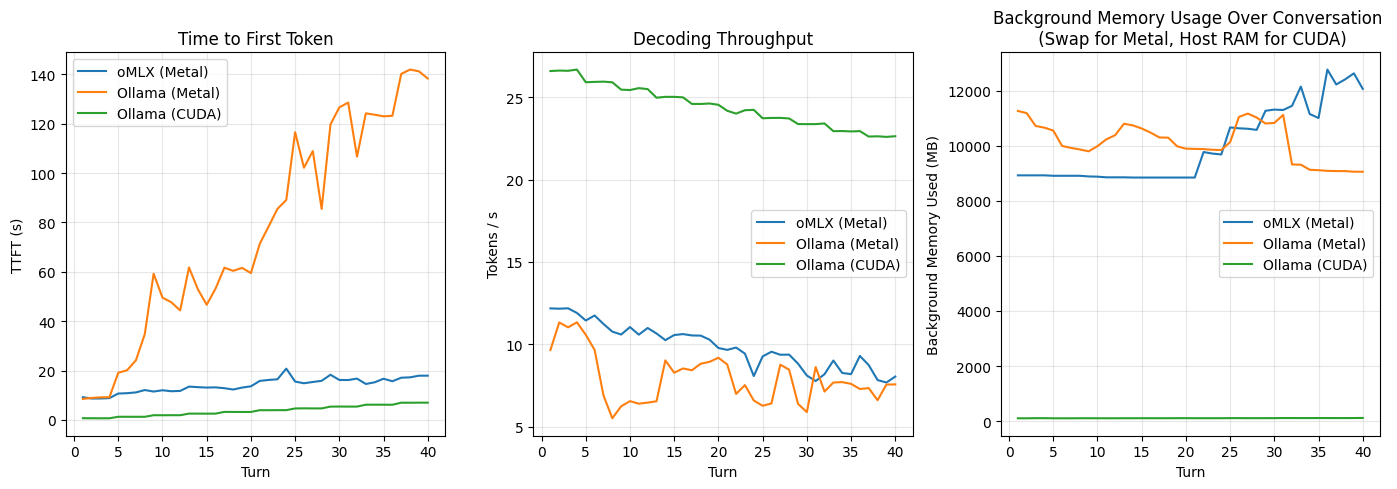

In [44]:
# Plot TTFT and decoding throughput over conversation turns

multi_conv_data = {
    "oMLX (Metal)": omlx_multi_conv_result,
    "Ollama (Metal)": ollama_metal_no_parallel_multi_conv_result,
    "Ollama (CUDA)": ollama_cuda_no_parallel_multi_conv_result,
}

def extract_metric_over_turns(runs: list[ConversationRunResult], metric: str) -> tuple[np.ndarray, np.ndarray]:
    """Extract a per-turn metric averaged across runs. Returns (means, stds) over flattened turns."""
    all_runs = []
    for run in runs:
        values = []
        for cycle in run.cycle_results:
            for agent in sorted(cycle.agent_results.keys()):
                values.append(getattr(cycle.agent_results[agent], metric))
        all_runs.append(values)
    arr = np.array(all_runs)  # (num_runs, num_turns)
    return arr.mean(axis=0), arr.std(axis=0)

num_turns = NUM_CYCLES * len(AGENTS)
turn_indices = np.arange(1, num_turns + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for label, runs in multi_conv_data.items():
    ttft_mean, ttft_std = extract_metric_over_turns(runs, "ttft_s")
    axes[0].plot(turn_indices, ttft_mean, label=label)
    axes[0].fill_between(turn_indices, ttft_mean - ttft_std, ttft_mean + ttft_std, alpha=0.2)

    tps_mean, tps_std = extract_metric_over_turns(runs, "gen_tps")
    axes[1].plot(turn_indices, tps_mean, label=label)
    axes[1].fill_between(turn_indices, tps_mean - tps_std, tps_mean + tps_std, alpha=0.2)
    
    mem_label = "host_ram_mb" if "CUDA" in label else "swap_used_mb"
    mem_mean, mem_std = extract_metric_over_turns(runs, mem_label)
    axes[2].plot(turn_indices, mem_mean, label=label)
    axes[2].fill_between(turn_indices, mem_mean - mem_std, mem_mean + mem_std, alpha=0.2)

axes[0].set_xlabel("Turn")
axes[0].set_ylabel("TTFT (s)")
axes[0].set_title("Time to First Token")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Turn")
axes[1].set_ylabel("Tokens / s")
axes[1].set_title("Decoding Throughput")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel("Turn")
axes[2].set_ylabel("Background Memory Used (MB)")
axes[2].set_title("Background Memory Usage Over Conversation \n (Swap for Metal, Host RAM for CUDA)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Concluding Remarks

The higher-level serving frameworks introduce negligible overhead on Apple Silicon, with `oMLX` and `Ollama` closely matching the throughput of their underlying engines. On CUDA, however, `Ollama` incurs a more substantial serving-layer penalty, approximately 50% of raw prefill throughput and 80% of decode throughput. This is likely due to additional CPU–GPU synchronisation costs that are absent in Apple Silicon's unified memory architecture.

For multi-conversation workloads, `oMLX`'s dynamic KV cache strategy proves considerably more effective on Apple Silicon than `Ollama`'s recomputation approach, maintaining controlled latency increasesacross conversation turns at the cost of swap activity. On CUDA, the latency penalty from `Ollama`'s recomputation strategy is much less pronounced, and the as the L4's higher compute throughput absorbs much of the recomputation overhead.

Overall, `oMLX` is the stronger serving framework on Apple Silicon, particularly for sustained multi-turn interactions. On CUDA, the architectural advantages of unified memory are absent, and `Ollama`'s recomputation strategy is less of a liability, though the serving-layer overhead relative to raw `llama.cpp` remains a consideration for latency-sensitive deployments and might make Apple Silicon a more cost-efficient option in this case.


# Limitations and Future Work

## Limitations

Several limitations of this study should be noted when interpreting the results:
1. **Hardware representativeness.** All Apple Silicon experiments were conducted on a single MacBook Air M4 with 24 GB of unified memory. In practice, users deploying LLM inference on Apple Silicon are more likely to use higher-end devices such as the Mac Studio with M4 Pro, Max, or Ultra chips, which offer greater memory capacity, higher memory bandwidth, and active cooling, and all of which could substantially affect both throughput and thermal behaviour. Higher-end configurations also change the cost-to-memory ratio considerably: a Mac Studio with 128 GB of unified memory is available for approximately $3,500, whereas a comparable CUDA setup (for example, four RTX 5090 GPUs with 32 GB of VRAM each) would cost upwards of $10,000 in GPUs alone. This has direct implications for the operational cost analysis in Experiment 2, which should be interpreted with this caveat in mind.
2. **Background process interference.** As the MacBook Air used in this study is a personal device, background OS activity could not be fully eliminated despite closing all non-essential processes. This may introduce variance into the measurements, and is a particular concern for the energy benchmarks, where even small fluctuations in idle load can affect net energy estimates.
3. **Incomplete energy accounting for CUDA.** The cluster energy measurements exclude CPU and DRAM consumption due to the absence of root access on the remote machine. This makes the Apple Silicon versus CUDA energy comparison asymmetric, and likely understates CUDA's true system-level power draw. As discussed in Experiment 2, correcting for this would further favour Apple Silicon in the energy and cost comparisons.
4. **Single model family.** All experiments use models from the Qwen2.5 family (7B, 4-bit quantisation). The conclusions drawn may not generalise to other model architectures, such as Kimi 2.5, Mistral, or the newer Qwen3.5 generations, or to workloads that stress different bottlenecks, such as mixture-of-experts architectures or long-context models; these might have significantly different memory access and compute profiles.
5. **Conflated quantisation and framework effects.** MLX and llama.cpp use different quantisation schemes (linear quantisation and GGUF $k$-means-based quantisation respectively) meaning that observed performance differences reflect a combination of framework-level optimisations and quantisation format effects. Disentangling these two factors would require a controlled experiment using identical quantisation formats across both frameworks, which is not currently supported.

# Conclusion

This report benchmarked two paradigms for running LLM inference on Apple Silicon, the MLX-native `mlx-lm` engine and the general-purpose `llama.cpp` engine, across raw performance, energy efficiency, and higher-level serving, comparing both against a CUDA baseline on an NVIDIA L4 GPU.

On raw inference performance, `mlx-lm` consistently outperforms `llama.cpp` on Apple Silicon, particularly for decode throughput at low bit-widths and across a range of batch sizes, where its more aggressive memory optimisations and consistent batch scaling seem to explain a meaningful edge. In prefill, the two frameworks perform comparably, but both are substantially outpaced by the L4 GPU, whose roughly 7x compute advantage makes it the clear choice for compute-intensive workloads. For decode, however, the gap narrows considerably to around 2.5x reflecting the more modest difference in memory bandwidth between the two platforms.

The energy analysis reveals a more nuanced picture. While CUDA is substantially more energy-efficient per token during prefill, this advantage reverses during decode, where Apple Silicon, particularly with `mlx-lm`, proves the more efficient platform. Accounting for idle power draw and the absence of CPU and DRAM measurements in the CUDA baseline further strengthens this finding. A simple operational cost model demonstrates that, across realistic prefill-to-decode ratios, Apple Silicon inference is approximately 2–3x more cost-effective than a comparable CUDA setup, suggesting it is a viable and economically attractive platform for consumer-hosted, decode-heavy inference workloads.

At the serving layer, `oMLX` and `Ollama` introduce negligible overhead on Apple Silicon relative to their underlying engines, while `Ollama` incurs a more significant penalty on CUDA, likely due to additional CPU–GPU synchronisation costs. For multi-conversation workloads, `oMLX`'s dynamic KV cache persistence strategy maintains consistent latency across conversation turns on Apple Silicon, whereas `Ollama`'s recomputation approach leads to progressively increasing latency. This gap narrows on CUDA, where higher compute throughput absorbs much of the recomputation cost.

Taken together, the results position `mlx-lm` as the generally favorable inference engine on Apple Silicon across all dimensions evaluated, and suggest that Apple Silicon is a compelling platform for cost-effective, single-user LLM inference, particularly for decode-heavy workloads. Its primary limitation remains compute throughput for prefill-intensive tasks, where CUDA retains a decisive advantage. We hope to future work extending this analysis to higher-end Apple Silicon hardware, broader model families, and full system-level energy accounting would further strengthen these conclusions.

# References
[1]: Ajayi, Oluwaseun A., and Ogundepo Odunayo. “Benchmarking On-Device Machine Learning on Apple Silicon with MLX.” arXiv:2510.18921. Preprint, arXiv, October 21, 2025. https://doi.org/10.48550/arXiv.2510.18921.

[2]: Barrios, Wayner. “Native LLM and MLLM Inference at Scale on Apple Silicon.” arXiv:2601.19139. Preprint, arXiv, January 29, 2026. https://doi.org/10.48550/arXiv.2601.19139.

[3]: Feng, Dahua, Zhiming Xu, Rongxiang Wang, and Felix Xiaozhu Lin. “Profiling Apple Silicon Performance for ML Training.” arXiv:2501.14925. Preprint, arXiv, January 28, 2025. https://doi.org/10.48550/arXiv.2501.14925.

[4]: Rajesh, Varun, Om Jodhpurkar, Pooja Anbuselvan, et al. “Production-Grade Local LLM Inference on Apple Silicon: A Comparative Study of MLX, MLC-LLM, Ollama, Llama.Cpp, and PyTorch MPS.” arXiv:2511.05502. Preprint, arXiv, October 9, 2025. https://doi.org/10.48550/arXiv.2511.05502.

[5] Hannun, Awni, Jagrit Digani, Angelos Katharopoulos, and Ronan Collobert. MLX: Efficient and Flexible Machine Learning on Apple Silicon. V. 0.0. Released 2023. https://github.com/ml-explore.

[6] You, Jie, Jae-Won Chung, and Mosharaf Chowdhury. “Zeus: Understanding and Optimizing GPU Energy Consumption of DNN Training.” Usenix Nsdi, 2023.

[7] Kim, Jun. Jundot/Omlx. Python. February 13, 2026, accessed March 23, 2026. https://github.com/jundot/omlx.

[8] Ollama. Ollama/Ollama. Go. June 26, 2023, accessed March 23, 2026. https://github.com/ollama/ollama.

[9] llama.cpp. Ggml-Org/Llama.Cpp. C++. March 10, 2023, accessed March 23, 2026. https://github.com/ggml-org/llama.cpp.

[10] mlx-lm. ML-Explore/MLX-LM. Python. February 29, 2024, accessed March 23, 2026. https://github.com/ml-explore/mlx-lm.